# Real-Time Rotational Dynamics & Edge-AI Payload Safety System



---

## Aim

To design and implement a lightweight, edge-deployable machine learning pipeline that classifies the rotational stability of a payload placed on a rotating platform as **SAFE (0)** or **UNSAFE / FALL / SLIDE / TIP (1)**, using only smartphone gyroscope data (X and Y axes) collected with the phyphox application.

## Problem Statement

A payload resting on a rotating platform experiences a centripetal force requirement that grows with angular velocity. Beyond a critical angular velocity, static friction can no longer supply the required centripetal force, and the payload slides, tips, or falls. This experiment uses smartphone gyroscope measurements (mounted on the rotating platform) to detect the onset of this instability in real time using a lightweight, TinyML-deployable classifier.

## Objectives

1. Acquire raw rotational data using a smartphone (phyphox) as the IMU sensor.
2. Restrict the sensing modality to gyroscope **X** and **Y** axes only (Z is intentionally excluded).
3. Preprocess, window, and extract statistical features from the raw signal.
4. Train a lightweight classical classifier (Decision Tree) to distinguish SAFE vs UNSAFE states.
5. Separately construct a small TensorFlow/Keras neural network, using the same feature set, purely to demonstrate a TensorFlow Lite (TFLite) conversion and deployment pipeline.
6. Benchmark the TFLite model **inside this notebook** (Colab/Jupyter) — no physical edge/smartphone deployment is performed.
7. Estimate the experimental coefficient of static friction (μs) from the critical angular velocity at which instability is observed.

## Experimental Concept

A smartphone is rigidly mounted to a rotating platform with phyphox recording gyroscope angular velocity. A payload object rests freely on the same platform. As rotational speed increases, the payload eventually loses static friction grip and slides/tips/falls. The gyroscope signal recorded by the smartphone (a proxy for the platform's angular velocity) is used to construct features that a lightweight ML model can learn to associate with the SAFE → UNSAFE transition.

## Exact 15-Step Workflow

1. Smartphone + phyphox
2. Gyroscope Axes (X and Y only)
3. Data Acquisition
4. Data Cleaning & Preprocessing
5. Time-Series Windowing
6. Feature Extraction (from X and Y)
7. Feature Matrix (X)
8. Labels (y)
9. Train/Test Split
10. Lightweight Classifier (Decision Tree)
11. Model Evaluation
12. TensorFlow Lite Conversion
13. TFLite Model
14. TensorFlow Lite Inference (inside notebook)
15. Deployment Metrics

## Dataset note (read before interpreting any result)

All 20 physical trials end in a fall. There are **no independently recorded SAFE trials**. In this notebook, **SAFE (0)** means *a window (of the length selected by the window-size ablation study) that ends at or before the recorded fall time inside a failure trial*; **UNSAFE (1)** means *a window that reaches or follows the fall*. The experiment is therefore a **pre-failure vs failure-window** classification demonstration, not a general SAFE-trial vs UNSAFE-trial classifier. Details and consequences are documented in Step 8, Step 9 and the closing limitation section.

## Imports & Dependencies




In [1]:
import os
import glob
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.20.0
All libraries imported successfully.


In [2]:
# --- Data locations ---
DATA_DIR          = Path("dataset")
RAW_DATA_DIR       = DATA_DIR / "raw"
RAW_DATA_FILENAME  = "Main_Raw Data.csv"          # single continuous phyphox gyroscope recording
RAW_DATA_PATH      = RAW_DATA_DIR / RAW_DATA_FILENAME
METADATA_PATH      = DATA_DIR / "metadata" / "trial_metadata.csv"

# --- Output locations (created, never overwrites raw data) ---
OUTPUT_DIR      = Path("outputs")
FIGURES_DIR     = OUTPUT_DIR / "figures"
PROCESSED_DIR   = OUTPUT_DIR / "processed"
MODELS_DIR      = OUTPUT_DIR / "models"
REPORTS_DIR     = OUTPUT_DIR / "reports"

for d in [RAW_DATA_DIR, METADATA_PATH.parent, FIGURES_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True) if d == METADATA_PATH.parent or d.suffix == "" else None

# --- Windowing parameters (Step 5) ---
# WINDOW_SIZE_SECONDS is the ML window length used by Steps 5-15. It starts at the
# original 3.0 s and is OVERWRITTEN by the window-size ablation study (section after
# Step 4) with the selected window. The ablation itself tests ABLATION_WINDOW_SIZES.
WINDOW_SIZE_SECONDS = 3.0
WINDOW_OVERLAP      = 0.5   # fractional overlap between consecutive windows (0 <= overlap < 1)
ABLATION_WINDOW_SIZES = [3.0, 1.0, 0.5, 0.25]   # window-size ablation (seconds)

# --- Stopwatch-recorded fall-event times (Step 3) ---
# Raw Data.csv is ONE continuous gyroscope recording containing 20 physical fall
# events (the gyroscope was never stopped between falls). These are the exact
# externally recorded stopwatch times (seconds) at which each fall was observed.
# DO NOT CHANGE THESE VALUES — they are experimental metadata, not something
# this notebook infers or recomputes.
EVENT_TIMES = [
    3.00, 5.75, 8.27, 11.89, 18.71,
    22.14, 25.94, 29.89, 32.51, 34.96,
    42.31, 44.76, 49.25, 52.09, 55.33,
    58.10, 60.65, 64.13, 68.37, 71.19,
]

# --- Trial / event segmentation (Step 3) - DECOUPLED from the ML window size ---
# Each of the 20 physical trials is carved out of the continuous recording as
# [event_time - EVENT_WINDOW_BEFORE, event_time + EVENT_WINDOW_AFTER], clamped at the
# midpoint to neighbouring recorded events so no two trials overlap.
#
# In the ORIGINAL notebook these widths were set equal to WINDOW_SIZE_SECONDS (3.0 s).
# For the window-size ablation they must NOT follow the ML window: otherwise a 0.25 s
# ML window would silently shrink every physical trial to 0.25 s before / after the
# fall, and the experiments would differ in their *trial boundaries* as well as in
# their window size. They are therefore fixed at SEGMENT_SECONDS = 3.0 s, which is
# exactly the segmentation the original notebook used, so the trial data are identical
# for all four ablation experiments (a shape/checksum assertion in the ablation
# section verifies this).
SEGMENT_SECONDS     = 3.0
EVENT_WINDOW_BEFORE = SEGMENT_SECONDS
EVENT_WINDOW_AFTER  = SEGMENT_SECONDS

# --- Window-level class labels (Step 8) ---
# SAFE   = a window that ends at/before the recorded failure_time of its trial
#          (NOT an independently recorded safe trial - every trial ends in a fall)
# UNSAFE = a window that reaches or follows the failure_time
SAFE   = 0
UNSAFE = 1

# --- Train/test split (Step 9) ---
TEST_SIZE    = 0.2          # ~80/20 split, trial-aware (GroupShuffleSplit)
RANDOM_STATE = 42
# The split stays group (trial) aware. Candidate splits are tried from seed
# RANDOM_STATE upward, and the first one in which BOTH train and test contain
# both classes is used. Only class presence is checked - never model scores.
SPLIT_SEARCH_MAX_SEEDS = 500

# --- Decision Tree hyperparameters (Step 10) ---
DT_MAX_DEPTH = 5

# --- Tiny Keras / TFLite model hyperparameters (Steps 10 TFLite variant, 12) ---
KERAS_EPOCHS     = 50
KERAS_BATCH_SIZE = 16

# --- Physics: static friction analysis constants ---
PAYLOAD_MASS_KG    = None   # e.g. 0.150  -> MUST be set by the user before physics analysis
ROTATION_RADIUS_M  = None   # e.g. 0.12   -> MUST be set by the user before physics analysis
GRAVITY            = 9.81   # m/s^2

# --- Reproducibility ---
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Configuration loaded.")
print(f"RAW_DATA_PATH  = {RAW_DATA_PATH.resolve()}")
print(f"METADATA_PATH  = {METADATA_PATH.resolve()}")
print(f"WINDOW_SIZE_SECONDS = {WINDOW_SIZE_SECONDS}, WINDOW_OVERLAP = {WINDOW_OVERLAP}")
print(f"Trial segmentation (fixed): EVENT_WINDOW_BEFORE = {EVENT_WINDOW_BEFORE}s, EVENT_WINDOW_AFTER = {EVENT_WINDOW_AFTER}s")
print(f"Ablation window sizes: {ABLATION_WINDOW_SIZES}")
print(f"Number of recorded fall events: {len(EVENT_TIMES)}")

Configuration loaded.
RAW_DATA_PATH  = /content/dataset/raw/Main_Raw Data.csv
METADATA_PATH  = /content/dataset/metadata/trial_metadata.csv
WINDOW_SIZE_SECONDS = 3.0, WINDOW_OVERLAP = 0.5
Trial segmentation (fixed): EVENT_WINDOW_BEFORE = 3.0s, EVENT_WINDOW_AFTER = 3.0s
Ablation window sizes: [3.0, 1.0, 0.5, 0.25]
Number of recorded fall events: 20


# Step 1 — Smartphone + phyphox

## Purpose
Document the physical data-acquisition setup. This step involves no code: it establishes how the raw gyroscope data (used in every later step) was physically obtained.

## Method
- A smartphone is used purely as an inertial measurement unit (IMU); no custom firmware or hardware is required.
- **phyphox** (an open-source physics experimentation app) records the built-in gyroscope stream and exports it as a **single CSV file**, `Raw Data.csv`.
- The **payload** (the object whose stability is being studied) is placed on top of the smartphone. As the phone is tilted/moved by hand, the payload eventually loses grip and falls.
- The experiment was carried out as **one continuous gyroscope recording covering all 20 trials**, not as 20 separate recordings:
  1. The payload is placed on the phone and the gyroscope recording is started.
  2. A second person starts a stopwatch at approximately the same time.
  3. The phone is tilted/moved. Whenever the payload falls, the second person notes the stopwatch time.
  4. The payload is picked up and placed back on the phone, **without stopping the gyroscope recording**.
  5. Steps 3–4 are repeated until all **20 physical fall events** have occurred, at which point the gyroscope recording is stopped.
- Because the recording is never paused between falls, the 20 trials are **not** 20 separate files — they are 20 segments of one continuous signal, located afterwards by matching the independently recorded stopwatch times (`EVENT_TIMES`, fixed in the Configuration cell) to the gyroscope's own timestamps.

## Implementation
No code is required for this step — it is documentation of the experimental protocol that produced the single raw CSV used from Step 3 onward.

## Output / Interpretation
The result of this step is not a computed value but the *existence* of one continuous phyphox CSV export (`Raw Data.csv`) containing all 20 fall events back-to-back, which Step 3 loads and segments into 20 trials using the stopwatch-recorded `EVENT_TIMES`.


# Step 2 — Gyroscope Axes (X and Y only)

## Purpose
Define precisely which sensor channels this pipeline is allowed to use, and the mathematical quantity derived from them.

## Method
This experiment uses **only**:
- Gyroscope **X** (angular velocity about the X axis)
- Gyroscope **Y** (angular velocity about the Y axis)

Gyroscope **Z is intentionally excluded** from every stage of this pipeline — it is never loaded into a feature, plot, or model input beyond initial raw inspection (if present in the CSV, it is dropped rather than used).

The combined in-plane angular magnitude used throughout this notebook is:

$$\omega_{xy} = \sqrt{\omega_x^2 + \omega_y^2}$$

**Not** the full 3-axis magnitude $\sqrt{\omega_x^2+\omega_y^2+\omega_z^2}$.

## Implementation
No code cell is required here — $\omega_{xy}$ is computed later (Steps 4 and 6) once real X/Y data has been loaded. A visualization of the raw X and Y signals is produced in Step 4, immediately after loading.

## Output / Interpretation
This step produces no data output; it fixes a design constraint that is enforced in every downstream computation (data acquisition, preprocessing, feature extraction, and the physics analysis).


## Column-Name Mapping Configuration

**What this step does:** Defines a small, explicit mapping between the (possibly inconsistent) column names used by different phyphox exports and the standardized internal names `timestamp`, `gyro_x`, `gyro_y` used throughout the rest of the notebook.

**Why it is required:** phyphox CSV exports are not guaranteed to use identical column names across app versions/locales (e.g. `Time (s)` vs `t (s)`, `Gyroscope x (rad/s)` vs `Wx (rad/s)`). Rather than assuming a fixed schema, this notebook attempts automatic detection and falls back to an explicit, user-editable dictionary.

**Input:** None yet — this cell only defines the mapping logic; it is applied once real CSVs are loaded in the next step.

**Output:** A `COLUMN_ALIASES` lookup table and a `standardize_columns()` helper function that will be reused for every trial CSV.


In [3]:
# ============================================================
# COLUMN MAPPING
# ============================================================
# Each internal standardized name maps to a list of plausible raw phyphox
# column-name variants (case-insensitive substring match is attempted first).

COLUMN_ALIASES = {
    "timestamp": ["time (s)", "t (s)", "time", "timestamp"],
    "gyro_x":    ["gyroscope x (rad/s)", "gyroscope x (deg/s)", "wx (rad/s)",
                  "gyro x", "gyroscope x", "x (rad/s)"],
    "gyro_y":    ["gyroscope y (rad/s)", "gyroscope y (deg/s)", "wy (rad/s)",
                  "gyro y", "gyroscope y", "y (rad/s)"],
}

# MANUAL OVERRIDE: if automatic detection below fails for your specific
# phyphox export, set the exact column names here (leave as None to rely
# on automatic detection).
MANUAL_COLUMN_MAP = {
    "timestamp": None,   # e.g. "Time (s)"
    "gyro_x":    None,   # e.g. "Gyroscope x (rad/s)"
    "gyro_y":    None,   # e.g. "Gyroscope y (rad/s)"
}


def detect_column(df_columns, candidates):
    """Case-insensitive substring match of candidate names against actual columns."""
    lowered = {c.lower(): c for c in df_columns}
    for cand in candidates:
        for lc, original in lowered.items():
            if cand.lower() in lc or lc in cand.lower():
                return original
    return None


def standardize_columns(df, verbose=False):
    """
    Map a raw phyphox dataframe's columns onto ['timestamp', 'gyro_x', 'gyro_y'].
    Uses MANUAL_COLUMN_MAP first (if set), otherwise falls back to automatic
    detection via COLUMN_ALIASES. Raises a clear error if a required column
    cannot be resolved either way. Gyroscope Z (if present) is dropped.
    """
    resolved = {}
    for std_name, aliases in COLUMN_ALIASES.items():
        manual = MANUAL_COLUMN_MAP.get(std_name)
        if manual is not None:
            if manual not in df.columns:
                raise ValueError(
                    f"MANUAL_COLUMN_MAP['{std_name}'] = '{manual}' not found in "
                    f"columns: {list(df.columns)}"
                )
            resolved[std_name] = manual
        else:
            found = detect_column(df.columns, aliases)
            if found is None:
                raise ValueError(
                    f"Could not automatically detect a column for '{std_name}'. "
                    f"Available columns: {list(df.columns)}. "
                    f"Please set MANUAL_COLUMN_MAP['{std_name}'] explicitly."
                )
            resolved[std_name] = found

    if verbose:
        print("Resolved column mapping:", resolved)

    out = df[[resolved["timestamp"], resolved["gyro_x"], resolved["gyro_y"]]].copy()
    out.columns = ["timestamp", "gyro_x", "gyro_y"]
    return out


print("Column mapping configuration ready.")
print("COLUMN_ALIASES:", json.dumps(COLUMN_ALIASES, indent=2))

Column mapping configuration ready.
COLUMN_ALIASES: {
  "timestamp": [
    "time (s)",
    "t (s)",
    "time",
    "timestamp"
  ],
  "gyro_x": [
    "gyroscope x (rad/s)",
    "gyroscope x (deg/s)",
    "wx (rad/s)",
    "gyro x",
    "gyroscope x",
    "x (rad/s)"
  ],
  "gyro_y": [
    "gyroscope y (rad/s)",
    "gyroscope y (deg/s)",
    "wy (rad/s)",
    "gyro y",
    "gyroscope y",
    "y (rad/s)"
  ]
}


# Step 3 — Data Acquisition

## Purpose
Load the **single continuous** phyphox gyroscope recording (`Raw Data.csv`), which
contains all **20 physical fall events** back-to-back (the gyroscope was never
stopped between falls), and use the externally recorded stopwatch times
(`EVENT_TIMES`) to carve that one recording into 20 trial-level segments — each
behaving exactly like one of the "separate trial CSVs" the rest of this notebook
was originally built to expect.

## Method
1. Load `RAW_DATA_PATH` as a single dataframe, detect its columns (time, gyro X,
   gyro Y, and gyro Z if present), and report the raw sample count, recording
   duration, and estimated sampling frequency directly from the data — nothing
   here is hard-coded.
2. Standardize columns to `timestamp`, `gyro_x`, `gyro_y` via the existing
   `standardize_columns()` helper (Gyroscope Z, if present, is only reported for
   reference — it is never carried into the ML pipeline, per Step 2).
3. Match each of the 20 `EVENT_TIMES` to its **nearest actual gyroscope
   timestamp** in the recording (the stopwatch and the phyphox clock do not
   share a guaranteed common origin), producing a
   `Trial | Event Time (s) | Matched Gyro Time | Event Index` table.
4. Segment the continuous recording around each matched event into a
   `[event − EVENT_WINDOW_BEFORE, event + EVENT_WINDOW_AFTER]` slice, **clamped
   so adjacent trial segments never overlap** (several real events are closer
   together than `2 × WINDOW_SIZE_SECONDS`). Each slice is tagged with a
   `trial_id` (`trial_01` … `trial_20`), exactly matching the schema the rest of
   the notebook already expects.
5. Concatenate the 20 segments into `master_df` — same columns
   (`trial_id, timestamp, gyro_x, gyro_y`) the original multi-file loader
   produced.

## Implementation
This is real, executable code against the actual `Raw Data.csv` — every number
reported (sample count, duration, sampling rate, matched timestamps, per-trial
sample counts) comes from the file itself, never invented.

## Output / Interpretation
`master_df`: one dataframe with columns `[trial_id, timestamp, gyro_x, gyro_y]`
covering the 20 segmented trials. `event_table_df` makes the stopwatch-to-gyroscope
mapping transparent. A verification plot (added right after this step) overlays
the 20 matched event times on the full continuous signal.


In [4]:
# --- 1. Load the single continuous raw recording ---
if RAW_DATA_PATH.exists():
    raw_df = pd.read_csv(RAW_DATA_PATH)
    print(f"Loaded raw recording: {RAW_DATA_PATH.resolve()}")
else:
    raw_df = pd.DataFrame()
    print(f"[WARNING] Raw data file not found at {RAW_DATA_PATH.resolve()}. "
          f"Place the phyphox export there (as '{RAW_DATA_FILENAME}') and re-run this cell.")

if not raw_df.empty:
    print("\nRaw columns found:", list(raw_df.columns))

    # --- 2. Standardize to timestamp/gyro_x/gyro_y (reuses the column-mapping
    #         helper from Step 2/3 config). Gyroscope Z, if present, is detected
    #         and reported below for reference only — never used in the ML
    #         feature pipeline, per Step 2. ---
    std_df = standardize_columns(raw_df, verbose=True)
    std_df = std_df.sort_values("timestamp").reset_index(drop=True)

    z_candidates = ["gyroscope z (rad/s)", "gyroscope z (deg/s)", "wz (rad/s)",
                     "gyro z", "gyroscope z", "z (rad/s)"]
    z_col_name = detect_column(raw_df.columns, z_candidates)
    if z_col_name is not None:
        print(f"Detected Gyroscope Z column: '{z_col_name}' "
              f"(kept for reference only — NOT used anywhere in the ML feature pipeline).")
    else:
        print("No Gyroscope Z column detected (not required — this pipeline only uses X and Y).")

    # --- 3. Dataset-level reporting: shape, duration, sampling frequency ---
    n_raw_samples = len(std_df)
    recording_duration = float(std_df["timestamp"].max() - std_df["timestamp"].min())
    dt_all = std_df["timestamp"].diff().dropna()
    est_sampling_hz = float(1.0 / dt_all.median()) if len(dt_all) else float("nan")

    print(f"\nNumber of raw samples   : {n_raw_samples}")
    print(f"Recording duration (s)  : {recording_duration:.3f}")
    print(f"Estimated sampling freq : {est_sampling_hz:.2f} Hz (median dt = {dt_all.median():.6f} s)")

    # --- 4. Match each stopwatch EVENT_TIME to the nearest ACTUAL gyro timestamp ---
    ts_values = std_df["timestamp"].values
    event_rows = []
    for i, event_time in enumerate(EVENT_TIMES):
        nearest_idx = int(np.argmin(np.abs(ts_values - event_time)))
        event_rows.append({
            "trial_id": f"trial_{i + 1:02d}",
            "trial": i + 1,
            "event_time_s": event_time,
            "matched_gyro_time_s": float(ts_values[nearest_idx]),
            "event_index": nearest_idx,
        })
    event_table_df = pd.DataFrame(event_rows)

    # --- 5. Gap-aware segmentation: carve 20 non-overlapping trial windows
    #         around each matched event, using EVENT_WINDOW_BEFORE/AFTER but
    #         clamped at the midpoint to the neighboring RECORDED event whenever
    #         the real gap between two consecutive falls is smaller than
    #         EVENT_WINDOW_BEFORE + EVENT_WINDOW_AFTER. This clamp is only a
    #         leakage-prevention safeguard: the *primary* segmentation boundary
    #         is always the recorded EVENT_TIMES themselves — this never divides
    #         the recording into arbitrary equal sections. ---
    t_min, t_max = float(ts_values.min()), float(ts_values.max())
    n_events = len(EVENT_TIMES)
    seg_starts, seg_ends = [], []
    for i, event_time in enumerate(EVENT_TIMES):
        left_neighbor = t_min if i == 0 else EVENT_TIMES[i - 1]
        right_neighbor = t_max if i == n_events - 1 else EVENT_TIMES[i + 1]
        clamp_before = left_neighbor if i == 0 else (event_time + left_neighbor) / 2.0
        clamp_after = right_neighbor if i == n_events - 1 else (event_time + right_neighbor) / 2.0
        seg_starts.append(max(event_time - EVENT_WINDOW_BEFORE, clamp_before, t_min))
        seg_ends.append(min(event_time + EVENT_WINDOW_AFTER, clamp_after, t_max))

    event_table_df["segment_start_s"] = seg_starts
    event_table_df["segment_end_s"] = seg_ends

    # --- 6. Slice the continuous recording into 20 trial-level dataframes ---
    trial_frames = []
    trial_load_report = []
    for _, row in event_table_df.iterrows():
        tid = row["trial_id"]
        seg = std_df[(std_df["timestamp"] >= row["segment_start_s"]) &
                      (std_df["timestamp"] <= row["segment_end_s"])].copy()
        seg["trial_id"] = tid
        trial_frames.append(seg[["trial_id", "timestamp", "gyro_x", "gyro_y"]])
        trial_load_report.append({
            "trial_id": tid,
            "status": "loaded" if len(seg) > 0 else "empty_segment",
            "n_samples": len(seg),
        })

    master_df = pd.concat(trial_frames, ignore_index=True) if trial_frames else \
        pd.DataFrame(columns=["trial_id", "timestamp", "gyro_x", "gyro_y"])

    # --- 7. Auto-derived trial metadata. By the experiment's own design, every
    #         one of these 20 segments ends in an observed fall, so every trial
    #         is UNSAFE (label=1) at the trial level, with failure_time = that
    #         trial's own matched fall timestamp. This is NOT an invented label
    #         — it follows directly from how the data was physically collected.
    #         Step 8's existing per-window labelling rule then splits each
    #         trial's windows into SAFE (before the fall) / UNSAFE (at or after
    #         the fall) exactly as already defined, unchanged. ---
    auto_metadata_df = event_table_df[["trial_id", "matched_gyro_time_s"]].rename(
        columns={"matched_gyro_time_s": "failure_time"}
    ).copy()
    auto_metadata_df["label"] = 1
    auto_metadata_df = auto_metadata_df[["trial_id", "label", "failure_time"]]

else:
    std_df = pd.DataFrame(columns=["timestamp", "gyro_x", "gyro_y"])
    event_table_df = pd.DataFrame(columns=["trial_id", "trial", "event_time_s",
                                            "matched_gyro_time_s", "event_index",
                                            "segment_start_s", "segment_end_s"])
    trial_frames = []
    trial_load_report = []
    master_df = pd.DataFrame(columns=["trial_id", "timestamp", "gyro_x", "gyro_y"])
    auto_metadata_df = pd.DataFrame(columns=["trial_id", "label", "failure_time"])

# --- 8. Report acquisition statistics (mirrors the original per-trial summary) ---
load_report_df = pd.DataFrame(trial_load_report)
print("\n=== Trial Load Report ===")
print(load_report_df if not load_report_df.empty else "No trials loaded.")

if not master_df.empty:
    duration_rows = []
    for tid, g in master_df.groupby("trial_id"):
        duration_rows.append({
            "trial_id": tid,
            "n_samples": len(g),
            "duration_s": float(g["timestamp"].max() - g["timestamp"].min()) if len(g) > 1 else 0.0,
        })
    trial_duration_df = pd.DataFrame(duration_rows)
    print("\n=== Per-Trial Duration Summary ===")
    print(trial_duration_df)

    print(f"\nTotal trials loaded : {master_df['trial_id'].nunique()}")
    print(f"Total raw samples   : {len(master_df)}")

    empty_trials = load_report_df.loc[load_report_df["n_samples"] == 0, "trial_id"].tolist() \
        if not load_report_df.empty else []
    if empty_trials:
        print(f"\n[NOTE] {len(empty_trials)} trial(s) produced 0 samples because their real "
              f"fall events are closer together than EVENT_WINDOW_BEFORE/AFTER allow without "
              f"overlapping a neighboring trial: {empty_trials}. This reflects the actual "
              f"spacing of the recorded falls, not a data error.")
else:
    trial_duration_df = pd.DataFrame(columns=["trial_id", "n_samples", "duration_s"])
    print("\nSummary not available until data is provided.")


Loaded raw recording: /content/dataset/raw/Main_Raw Data.csv

Raw columns found: ['Time (s)', 'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)', 'Absolute (rad/s)']
Resolved column mapping: {'timestamp': 'Time (s)', 'gyro_x': 'Gyroscope x (rad/s)', 'gyro_y': 'Gyroscope y (rad/s)'}
Detected Gyroscope Z column: 'Gyroscope z (rad/s)' (kept for reference only — NOT used anywhere in the ML feature pipeline).

Number of raw samples   : 35846
Recording duration (s)  : 71.669
Estimated sampling freq : 500.15 Hz (median dt = 0.001999 s)

=== Trial Load Report ===
    trial_id  status  n_samples
0   trial_01  loaded       2182
1   trial_02  loaded       1318
2   trial_03  loaded       1536
3   trial_04  loaded       2405
4   trial_05  loaded       2357
5   trial_06  loaded       1808
6   trial_07  loaded       1938
7   trial_08  loaded       1642
8   trial_09  loaded       1267
9   trial_10  loaded       2114
10  trial_11  loaded       2113
11  trial_12  loaded       1736
12  t

## Event / Trial Table & Continuous Recording Verification

**What this shows:** the explicit mapping between the 20 externally recorded
stopwatch fall times and the nearest actual gyroscope timestamp found in
`Raw Data.csv`, plus a plot of the full continuous recording with all 20
matched fall events marked — so the relationship between the stopwatch
measurements and the raw sensor data is fully transparent and visually
verifiable before any windowing or feature extraction happens.


 Trial  Event Time (s)  Matched Gyro Time (s)  Event Index
     1            3.00               2.999542         1494
     2            5.75               5.749245         2869
     3            8.27               8.270300         4130
     4           11.89              11.889227         5940
     5           18.71              18.709150         9350
     6           22.14              22.139285        11065
     7           25.94              25.940789        12966
     8           29.89              29.890985        14941
     9           32.51              32.509365        16250
    10           34.96              34.960640        17476
    11           42.31              42.310010        21152
    12           44.76              44.759048        22377
    13           49.25              49.249847        24624
    14           52.09              52.089267        26045
    15           55.33              55.329427        27666
    16           58.10              58.099561        290

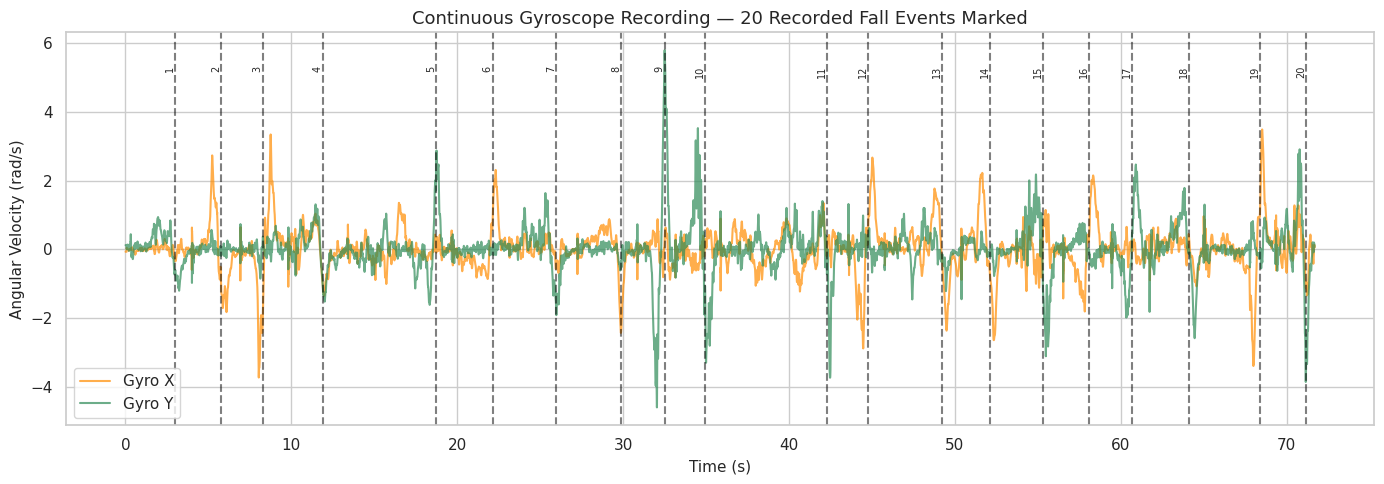

In [5]:
# --- Trial / Event table (Trial | Event Time (s) | Matched Gyro Time | Event Index) ---
if not event_table_df.empty:
    display_table = event_table_df[["trial", "event_time_s", "matched_gyro_time_s", "event_index"]].rename(
        columns={
            "trial": "Trial",
            "event_time_s": "Event Time (s)",
            "matched_gyro_time_s": "Matched Gyro Time (s)",
            "event_index": "Event Index",
        }
    )
    print(display_table.to_string(index=False))
else:
    print("Event table not available until data is provided.")

# --- Continuous recording plot with the 20 matched fall events marked ---
if not std_df.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(std_df["timestamp"], std_df["gyro_x"], color="darkorange", alpha=0.7, label="Gyro X")
    ax.plot(std_df["timestamp"], std_df["gyro_y"], color="seagreen", alpha=0.7, label="Gyro Y")

    ymax = max(std_df["gyro_x"].max(), std_df["gyro_y"].max())
    for _, row in event_table_df.iterrows():
        ax.axvline(row["matched_gyro_time_s"], color="black", linestyle="--", alpha=0.5)
        ax.text(row["matched_gyro_time_s"], ymax * 0.92, str(int(row["trial"])),
                rotation=90, fontsize=7, ha="right", va="top")

    ax.set_title("Continuous Gyroscope Recording — 20 Recorded Fall Events Marked")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity (rad/s)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "continuous_recording_event_markers.png", dpi=150)
    plt.show()
else:
    print("Continuous recording plot skipped — no data available yet.")


## Trial Metadata Loading & Validation

**What this step does:** Resolves the per-trial `label`/`failure_time` metadata (columns: `trial_id, label, failure_time`) needed for Step 8's labelling rule, then cross-validates it against the trials actually discovered in Step 3. This experiment did not supply a separate metadata file — only `Raw Data.csv` plus the 20 stopwatch times — so metadata is **auto-derived directly from Step 3's event/trial table**: by the experiment's own design, every one of the 20 segmented trials ends in an observed fall, so every trial is UNSAFE (`label = 1`) at the trial level, with `failure_time` set to that trial's own matched fall timestamp (`matched_gyro_time_s`). This is not an invented label — it follows mechanically from how the falls were recorded. If an external `trial_metadata.csv` is later placed at `METADATA_PATH` (e.g. to hand-correct or extend the auto-derived labels), it is loaded instead and takes priority.

**Why it is required:** Labels must come from the experimental metadata, not be assumed. This cell verifies that every raw trial has a corresponding metadata entry, that labels are valid (`0` or `1`), that there are no duplicate `trial_id`s, and clearly reports any missing metadata rather than silently continuing.

**Input:** `METADATA_PATH` (an optional external override CSV), the `auto_metadata_df` derived in Step 3, and the set of `trial_id`s present in `master_df`.

**Output:** A validated `metadata_df` and a printed validation report (missing entries, invalid labels, duplicates).


In [6]:
if METADATA_PATH.exists():
    metadata_df = pd.read_csv(METADATA_PATH)
    print(f"Loaded metadata from {METADATA_PATH} with {len(metadata_df)} row(s) (external override).")
elif not auto_metadata_df.empty:
    # No external override supplied: fall back to the metadata derived directly
    # from the continuous recording in Step 3 (see the "Auto-derived trial
    # metadata" note there). This is not an invented label — every one of the
    # 20 segmented trials contains an observed fall by the experiment's own
    # design, so every trial is UNSAFE (label=1) at the trial level, with
    # failure_time = that trial's own matched fall timestamp.
    metadata_df = auto_metadata_df.copy()
    print(f"No external metadata override found at {METADATA_PATH}. "
          f"Using metadata auto-derived from the 20 matched fall events "
          f"({len(metadata_df)} row(s)).")
else:
    metadata_df = pd.DataFrame(columns=["trial_id", "label", "failure_time"])
    print(f"[WARNING] Metadata file not found at {METADATA_PATH} and no trials were "
          f"segmented in Step 3. Create {METADATA_PATH} with columns: "
          f"trial_id, label, failure_time.")

validation_issues = []

# --- Duplicate trial IDs in metadata ---
if not metadata_df.empty:
    dup_ids = metadata_df["trial_id"][metadata_df["trial_id"].duplicated()].unique().tolist()
    if dup_ids:
        validation_issues.append(f"Duplicate trial_id entries in metadata: {dup_ids}")
        metadata_df = metadata_df.drop_duplicates(subset="trial_id", keep="first")

# --- Invalid labels ---
if not metadata_df.empty and "label" in metadata_df.columns:
    invalid_labels = metadata_df[~metadata_df["label"].isin([0, 1])]
    if not invalid_labels.empty:
        validation_issues.append(
            f"Invalid label values found (must be 0 or 1): "
            f"{invalid_labels[['trial_id', 'label']].to_dict('records')}"
        )

# --- Trials present in raw data but missing metadata ---
raw_trial_ids = set(master_df["trial_id"].unique()) if not master_df.empty else set()
meta_trial_ids = set(metadata_df["trial_id"].unique()) if not metadata_df.empty else set()

missing_metadata = sorted(raw_trial_ids - meta_trial_ids)
missing_raw = sorted(meta_trial_ids - raw_trial_ids)

if missing_metadata:
    validation_issues.append(f"Raw trials with NO metadata entry: {missing_metadata}")
if missing_raw:
    validation_issues.append(f"Metadata entries with NO matching raw CSV: {missing_raw}")

print("\n=== Metadata Validation Report ===")
if validation_issues:
    for issue in validation_issues:
        print("  [ISSUE]", issue)
else:
    print("  No validation issues found." if (raw_trial_ids or meta_trial_ids)
          else "  Not available until data is provided.")

No external metadata override found at dataset/metadata/trial_metadata.csv. Using metadata auto-derived from the 20 matched fall events (20 row(s)).

=== Metadata Validation Report ===
  No validation issues found.


## Reusable Data Quality Checks

**What this step does:** Defines a single `run_quality_checks()` function that screens the master dataframe for the full set of data-quality problems required by this experiment: empty files, missing/non-numeric columns, missing/duplicate timestamps, NaNs, infinities, very short trials, class imbalance, and insufficient trial counts.

**Why it is required:** Rather than silently continuing on bad data (which could quietly corrupt every downstream stage), this function raises clear, informative warnings/errors so problems are caught immediately after loading.

**Input:** `master_df`, `metadata_df`.

**Output:** A printed diagnostic report. This function is called again later (post-cleaning, post-labelling) to re-verify data health at each major stage.


In [7]:
def run_quality_checks(df, meta=None, stage="unspecified"):
    """Run a battery of data-quality checks and print a report. Never silently
    continues past a structural problem: known issues are always surfaced."""
    print(f"\n=== Data Quality Report [{stage}] ===")

    if df is None or df.empty:
        print("  [ISSUE] Dataframe is empty — no data available yet.")
        return

    # Missing columns
    required_cols = {"trial_id", "timestamp", "gyro_x", "gyro_y"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        print(f"  [ISSUE] Missing required columns: {missing_cols}")

    # Non-numeric gyro values
    for col in ["gyro_x", "gyro_y"]:
        if col in df.columns:
            non_numeric = pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna()
            if non_numeric.any():
                print(f"  [ISSUE] {non_numeric.sum()} non-numeric value(s) found in '{col}'.")

    # NaNs
    nan_counts = df[[c for c in ["timestamp", "gyro_x", "gyro_y"] if c in df.columns]].isna().sum()
    if nan_counts.sum() > 0:
        print(f"  [ISSUE] NaN values found:\n{nan_counts[nan_counts > 0]}")

    # Infinite values
    numeric_df = df.select_dtypes(include=[np.number])
    inf_counts = np.isinf(numeric_df).sum()
    if inf_counts.sum() > 0:
        print(f"  [ISSUE] Infinite values found:\n{inf_counts[inf_counts > 0]}")

    # Duplicate timestamps within a trial
    if {"trial_id", "timestamp"}.issubset(df.columns):
        dup_ts = df.duplicated(subset=["trial_id", "timestamp"]).sum()
        if dup_ts > 0:
            print(f"  [ISSUE] {dup_ts} duplicate (trial_id, timestamp) row(s) found.")

    # Very short trials (fewer than a few samples)
    if "trial_id" in df.columns:
        counts = df.groupby("trial_id").size()
        short_trials = counts[counts < 10]
        if not short_trials.empty:
            print(f"  [ISSUE] Very short trials (<10 samples): {short_trials.to_dict()}")

    # Number of trials
    n_trials = df["trial_id"].nunique() if "trial_id" in df.columns else 0
    if n_trials < 2:
        print(f"  [ISSUE] Insufficient number of trials for train/test splitting (found {n_trials}).")

    # Class balance (only if metadata provided)
    if meta is not None and not meta.empty and "label" in meta.columns:
        counts = meta["label"].value_counts()
        if 0 not in counts.index:
            print("  [ISSUE] No SAFE (label=0) trials found in metadata.")
        if 1 not in counts.index:
            print("  [ISSUE] No UNSAFE (label=1) trials found in metadata.")
        if len(counts) == 2 and (counts.min() / counts.sum()) < 0.2:
            print(f"  [WARNING] Class imbalance detected in metadata: {counts.to_dict()}")

    print(f"  Rows checked: {len(df)}, Trials checked: {n_trials}")


run_quality_checks(master_df, metadata_df, stage="post-acquisition")


=== Data Quality Report [post-acquisition] ===
  [ISSUE] No SAFE (label=0) trials found in metadata.
  Rows checked: 34761, Trials checked: 20


# Step 4 — Data Cleaning & Preprocessing

## Purpose
Inspect, clean, and prepare the raw master dataframe for windowing: check data types, missing values, duplicates, and invalid numeric entries; convert and sort timestamps; compute per-trial sampling statistics; and visualise the raw signals.

## Method
- Inspect dtypes and run `.info()` / `.describe()` on `master_df`.
- Quantify missing values per column and per trial.
- Remove exact duplicate rows.
- Coerce `gyro_x`/`gyro_y` to numeric, dropping rows that cannot be parsed (reported, not silently interpolated).
- Convert `timestamp` to numeric seconds and **sort each trial by timestamp** (never across trials).
- Compute the sampling interval (Δt) distribution per trial to assess sensor sampling-rate stability — this informs whether interpolation is warranted (a decision documented here, not applied blindly).
- Produce diagnostic plots: missing-value summary, sampling-interval distribution, raw X, raw Y, and a combined X/Y view for a representative trial.

## Implementation
All operations below act only on the `master_df` produced in Step 3; if that dataframe is empty (no data yet), the cleaning steps still run safely and simply report "no data" rather than crashing or fabricating values.

## Output / Interpretation
`clean_df`: a cleaned, sorted, per-trial-consistent dataframe ready for windowing. Diagnostic plots and printed sampling statistics reveal whether the recording was consistent enough for fixed-size windowing (Step 5); genuinely large sampling gaps would justify revisiting acquisition rather than being silently smoothed over.


=== dtypes ===
trial_id      object
timestamp    float64
gyro_x       float64
gyro_y       float64
dtype: object

=== Missing values per column ===
trial_id     0
timestamp    0
gyro_x       0
gyro_y       0
dtype: int64

Exact duplicate rows: 0

Dropped 0 row(s) with missing timestamp/gyro_x/gyro_y (explicit removal — no blanket interpolation applied).

=== Per-Trial Sampling Statistics ===
    trial_id  n_samples  duration_s   mean_dt        std_dt    min_dt  \
0   trial_01       2182    4.361924  0.002000  9.557617e-07  0.001997   
1   trial_02       1318    2.633304  0.001999  8.749425e-07  0.001997   
2   trial_03       1536    3.068690  0.001999  9.698014e-07  0.001996   
3   trial_04       2405    4.808184  0.002000  8.792916e-07  0.001997   
4   trial_05       2357    4.711852  0.002000  7.857763e-07  0.001997   
5   trial_06       1808    3.613732  0.002000  8.443658e-07  0.001997   
6   trial_07       1938    3.873737  0.002000  8.413502e-07  0.001997   
7   trial_08       16

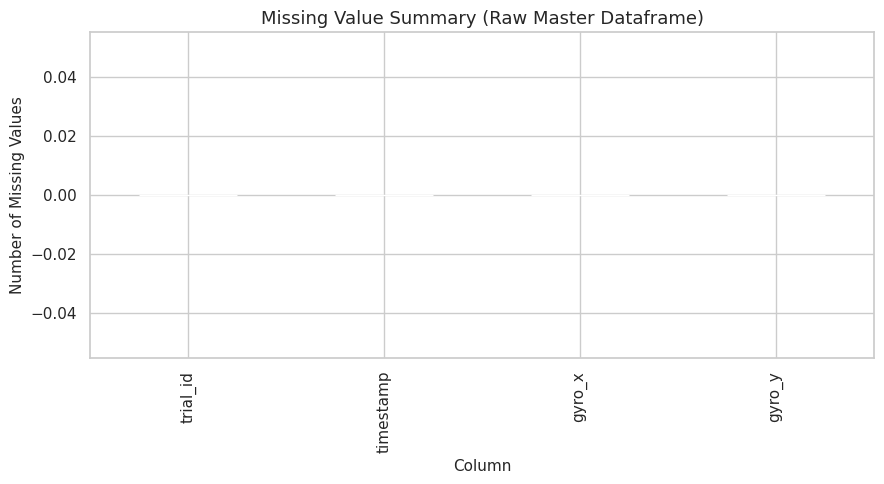

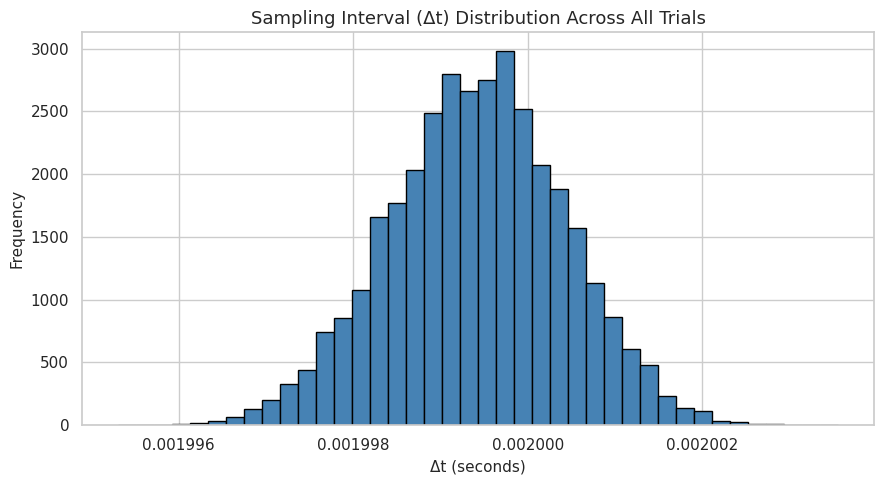

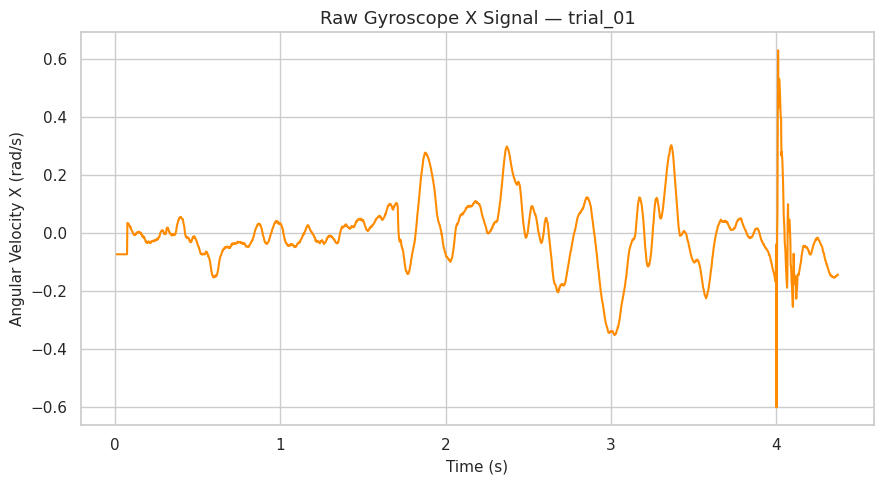

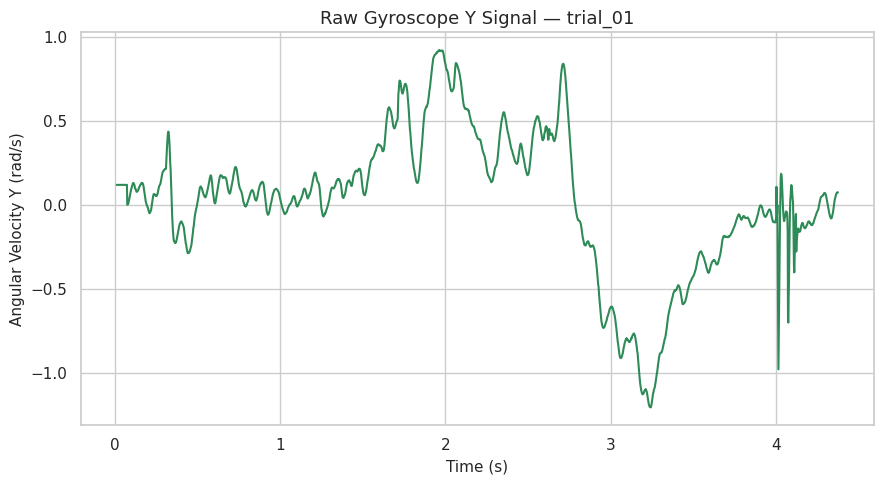

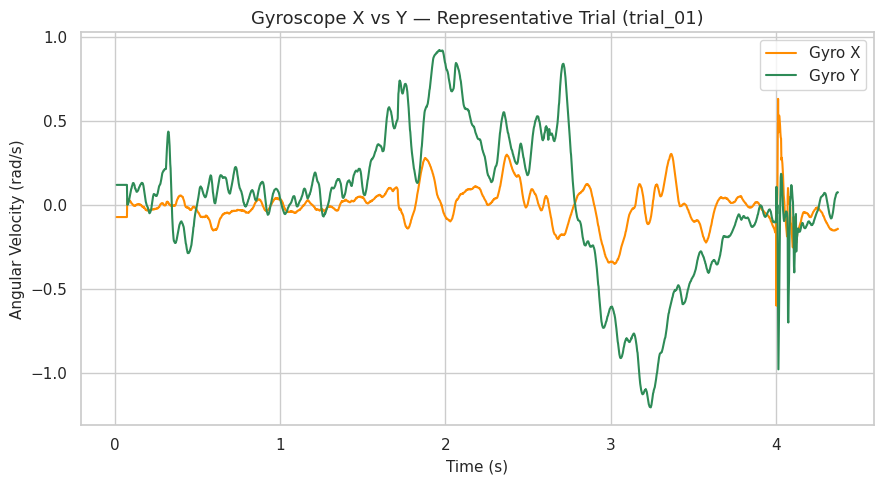

In [8]:
clean_df = master_df.copy()

print("=== dtypes ===")
print(clean_df.dtypes)

print("\n=== Missing values per column ===")
missing_summary = clean_df.isna().sum()
print(missing_summary)

# --- Duplicate rows ---
n_dupes = clean_df.duplicated().sum()
print(f"\nExact duplicate rows: {n_dupes}")
clean_df = clean_df.drop_duplicates()

# --- Coerce gyro columns to numeric; report (don't silently drop) invalid entries ---
for col in ["gyro_x", "gyro_y"]:
    before_na = clean_df[col].isna().sum() if col in clean_df.columns else 0
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")
        after_na = clean_df[col].isna().sum()
        introduced = after_na - before_na
        if introduced > 0:
            print(f"[INFO] {introduced} non-numeric '{col}' value(s) coerced to NaN.")

# --- Timestamp conversion & per-trial sorting (never mixing trials) ---
if "timestamp" in clean_df.columns:
    clean_df["timestamp"] = pd.to_numeric(clean_df["timestamp"], errors="coerce")
    clean_df = clean_df.sort_values(["trial_id", "timestamp"]).reset_index(drop=True)

# --- Drop rows with missing X/Y or timestamp (explicit choice, not blind interpolation) ---
before_rows = len(clean_df)
clean_df = clean_df.dropna(subset=["timestamp", "gyro_x", "gyro_y"])
after_rows = len(clean_df)
print(f"\nDropped {before_rows - after_rows} row(s) with missing timestamp/gyro_x/gyro_y "
      f"(explicit removal — no blanket interpolation applied).")

# --- Per-trial sampling interval statistics ---
sampling_stats = []
for tid, g in clean_df.groupby("trial_id"):
    dt = g["timestamp"].diff().dropna()
    if len(dt) > 0:
        sampling_stats.append({
            "trial_id": tid,
            "n_samples": len(g),
            "duration_s": float(g["timestamp"].max() - g["timestamp"].min()),
            "mean_dt": float(dt.mean()),
            "std_dt": float(dt.std()),
            "min_dt": float(dt.min()),
            "max_dt": float(dt.max()),
        })
sampling_stats_df = pd.DataFrame(sampling_stats)
print("\n=== Per-Trial Sampling Statistics ===")
print(sampling_stats_df if not sampling_stats_df.empty else "Not available until data is provided.")

run_quality_checks(clean_df, metadata_df, stage="post-cleaning")

# ---------------------------------------------------------------
# Plot 1: Missing-value summary
# ---------------------------------------------------------------
fig, ax = plt.subplots()
missing_summary.plot(kind="bar", ax=ax, color="indianred")
ax.set_title("Missing Value Summary (Raw Master Dataframe)")
ax.set_xlabel("Column")
ax.set_ylabel("Number of Missing Values")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_value_summary.png", dpi=150)
plt.show()

# ---------------------------------------------------------------
# Plot 2: Sampling interval distribution
# ---------------------------------------------------------------
if not sampling_stats_df.empty:
    all_dt = clean_df.groupby("trial_id")["timestamp"].diff().dropna()
    fig, ax = plt.subplots()
    ax.hist(all_dt, bins=40, color="steelblue", edgecolor="black")
    ax.set_title("Sampling Interval (Δt) Distribution Across All Trials")
    ax.set_xlabel("Δt (seconds)")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "sampling_interval_distribution.png", dpi=150)
    plt.show()
else:
    print("Sampling interval plot skipped — no data available yet.")

# ---------------------------------------------------------------
# Plot 3 & 4: Raw X and Raw Y signals (representative trial)
# Plot 5: Combined X/Y view for that trial
# ---------------------------------------------------------------
if not clean_df.empty:
    representative_trial = sorted(clean_df["trial_id"].unique())[0]
    trial_data = clean_df[clean_df["trial_id"] == representative_trial]

    fig, ax = plt.subplots()
    ax.plot(trial_data["timestamp"], trial_data["gyro_x"], color="darkorange")
    ax.set_title(f"Raw Gyroscope X Signal — {representative_trial}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity X (rad/s)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "raw_gyro_x_signal.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(trial_data["timestamp"], trial_data["gyro_y"], color="seagreen")
    ax.set_title(f"Raw Gyroscope Y Signal — {representative_trial}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity Y (rad/s)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "raw_gyro_y_signal.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(trial_data["timestamp"], trial_data["gyro_x"], label="Gyro X", color="darkorange")
    ax.plot(trial_data["timestamp"], trial_data["gyro_y"], label="Gyro Y", color="seagreen")
    ax.set_title(f"Gyroscope X vs Y — Representative Trial ({representative_trial})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity (rad/s)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "raw_xy_comparison.png", dpi=150)
    plt.show()
else:
    print("Signal plots skipped — no data available yet.")

# Window-Size Ablation Study

## Purpose
The original notebook used a single 3.0 s window and produced only **18 usable windows (2 SAFE, 16 UNSAFE)**; the Decision Tree predicted UNSAFE for every test window (SAFE recall 0, balanced accuracy 0.5). This section tests whether a shorter window gives a more useful and scientifically defensible experiment.

Window sizes tested: **3.0 s, 1.0 s, 0.5 s, 0.25 s** - `WINDOW_OVERLAP = 0.5` for all.

## What is held constant (so window size is the only variable)
- Same continuous recording, same 20 trial segments, same `failure_time` per trial.
- Same six features `X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms`.
- Same labelling rule: SAFE = 0 if `window_end <= failure_time`, otherwise UNSAFE = 1 (a window that reaches/crosses the fall stays UNSAFE).
- Same Decision Tree (`max_depth = 5`, `random_state = 42`), **not re-tuned per window size**.
- Same group-aware split method (`GroupShuffleSplit`, `groups = trial_id`, `test_size = 0.2`).
- Same Keras architecture/optimizer/loss/epochs/batch size (used afterwards, only for the selected window).

## Trial segmentation is decoupled from the ML window size
Two different things were coupled in the original configuration:
- **A. Trial/event segmentation** - which part of the continuous recording belongs to each physical trial (`EVENT_WINDOW_BEFORE/AFTER`).
- **B. ML window size** - how each trial is divided into windows for feature extraction (`WINDOW_SIZE_SECONDS`).

Originally A was set equal to B (both 3.0 s). Changing B alone would therefore also have shrunk the physical trials (a 0.25 s ML window would have cut each trial to 0.25 s before/after the fall). A is now fixed at `SEGMENT_SECONDS = 3.0` (identical to the original segmentation) and only B varies. This is checked by an assertion below.

## Leakage prevention
Windows overlap by 50 %, so windows are **never** split individually. The split is by `trial_id`; for every experiment the notebook prints the number of train/test trials and the size of the intersection, and asserts it is **0**.

## Split seed rule (not performance-based)
Seeds are tried from `RANDOM_STATE` upward; the first group-aware split in which **both train and test contain both classes** is the documented split. Model scores are never looked at. To check that the conclusion does not hinge on that one split, up to `N_ROBUST_SPLITS` further valid group-aware splits are also evaluated per window size (same class-coverage criterion only) and summarised as mean +/- std.

## No fabricated data
No windows or trials are duplicated, no SMOTE, no sensor values are altered, no labels are reassigned, and test data are never used for training or quantization calibration.

## Shorter is not automatically better
Reducing the window size increases temporal resolution and generally produces more windows, but shorter windows may also contain less contextual information and may be more sensitive to sensor noise. Therefore, window size is selected based on class coverage, evaluation validity, and classification behaviour rather than accuracy alone.

In [9]:
# --- Shared pipeline helpers (moved here, unchanged, from Steps 5, 6 and 8 so that the
#     ablation and the main pipeline use IDENTICAL windowing / feature / label code) ---

def generate_windows(df, window_size_s, overlap_frac, trial_col="trial_id", time_col="timestamp"):
    """
    Generate (trial_id, window_start, window_end, start_idx, end_idx) tuples for
    every trial independently. Windows never cross trial boundaries. Uses the
    trial's own empirical sampling rate to convert the time-based window size
    into an approximate sample count.
    """
    window_rows = []

    for tid, g in df.groupby(trial_col):
        g = g.sort_values(time_col).reset_index(drop=True)
        if len(g) < 2:
            continue  # too short to estimate a sampling rate

        dt_median = g[time_col].diff().median()
        if pd.isna(dt_median) or dt_median <= 0:
            continue

        samples_per_window = max(int(round(window_size_s / dt_median)), 1)
        step = max(int(round(samples_per_window * (1 - overlap_frac))), 1)

        start_idx = 0
        while start_idx + samples_per_window <= len(g):
            end_idx = start_idx + samples_per_window
            window_rows.append({
                "trial_id": tid,
                "start_idx": start_idx,
                "end_idx": end_idx,          # exclusive
                "window_start": float(g[time_col].iloc[start_idx]),
                "window_end": float(g[time_col].iloc[end_idx - 1]),
            })
            start_idx += step

    return pd.DataFrame(window_rows)


def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(np.square(values)))) if len(values) else np.nan


def extract_features_from_window(x_vals, y_vals):
    """
    Compute the primary 6-feature vector [X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms]
    plus optional supplementary omega_xy statistics, from arrays of gyro_x/gyro_y
    samples belonging to a single window. Z is never used.
    """
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    omega_xy = np.sqrt(x_vals ** 2 + y_vals ** 2)  # X and Y only, per the workflow

    return {
        # --- PRIMARY feature vector (Decision Tree input) ---
        "X_mean": float(np.mean(x_vals)),
        "X_std":  float(np.std(x_vals)),
        "X_rms":  rms(x_vals),
        "Y_mean": float(np.mean(y_vals)),
        "Y_std":  float(np.std(y_vals)),
        "Y_rms":  rms(y_vals),
        # --- OPTIONAL supplementary features (NOT part of the primary vector) ---
        "omega_xy_mean": float(np.mean(omega_xy)),
        "omega_xy_std":  float(np.std(omega_xy)),
        "omega_xy_rms":  rms(omega_xy),
    }


def assign_labels(features_df, metadata_df):
    """
    Assign a 0/1 label to every window using the documented rule:
      - SAFE trial              -> all windows = 0
      - UNSAFE trial, no failure_time -> all windows = 1
      - UNSAFE trial, with failure_time:
            window fully before failure_time -> 0
            window overlapping or after failure_time -> 1
    """
    if features_df.empty or metadata_df.empty:
        return pd.Series(dtype="Int64"), pd.DataFrame(
            columns=["trial_id", "window_start", "window_end", "label"]
        )

    meta_lookup = metadata_df.set_index("trial_id")
    labels = []
    label_records = []

    for _, row in features_df.iterrows():
        tid = row["trial_id"]
        if tid not in meta_lookup.index:
            labels.append(pd.NA)
            continue

        trial_label = meta_lookup.loc[tid, "label"]
        failure_time = meta_lookup.loc[tid, "failure_time"] if "failure_time" in meta_lookup.columns else np.nan

        if trial_label == 0:
            window_label = 0
        else:  # trial_label == 1 (UNSAFE)
            if pd.isna(failure_time):
                window_label = 1
            else:
                if row["window_end"] <= failure_time:
                    window_label = 0
                else:  # overlaps or fully after failure_time
                    window_label = 1

        labels.append(window_label)
        label_records.append({
            "trial_id": tid,
            "window_start": row["window_start"],
            "window_end": row["window_end"],
            "label": window_label,
        })

    return pd.Series(labels, name="label"), pd.DataFrame(label_records)


PRIMARY_FEATURE_COLS = ["X_mean", "X_std", "X_rms", "Y_mean", "Y_std", "Y_rms"]
SUPPLEMENTARY_FEATURE_COLS = ["omega_xy_mean", "omega_xy_std", "omega_xy_rms"]
print("Shared helper functions defined: generate_windows, extract_features_from_window, assign_labels")

Shared helper functions defined: generate_windows, extract_features_from_window, assign_labels


In [10]:
N_ROBUST_SPLITS = 25          # extra valid group-aware splits per window size (stability check)
MIN_SAFE_TEST_ADEQUATE = 3    # minimum SAFE test windows to call SAFE-class coverage "adequate"


def build_labelled_features(df, meta, window_s, overlap):
    """Windows -> six primary features (+ omega_xy) -> labels, for ONE window size."""
    widx = generate_windows(df, window_s, overlap)
    cols = ["trial_id", "window_start", "window_end"] + PRIMARY_FEATURE_COLS + SUPPLEMENTARY_FEATURE_COLS
    if widx.empty:
        return pd.DataFrame(columns=cols + ["label"])
    rows = []
    for tid, g in df.groupby("trial_id"):
        g = g.sort_values("timestamp").reset_index(drop=True)
        for _, w in widx[widx["trial_id"] == tid].iterrows():
            sl = g.iloc[w["start_idx"]:w["end_idx"]]
            f = extract_features_from_window(sl["gyro_x"].values, sl["gyro_y"].values)
            f.update({"trial_id": tid, "window_start": w["window_start"], "window_end": w["window_end"]})
            rows.append(f)
    feats = pd.DataFrame(rows)[cols]
    labels, _ = assign_labels(feats, meta)
    feats["label"] = labels
    feats = feats.dropna(subset=["label"]).reset_index(drop=True)
    feats["label"] = feats["label"].astype(int)
    return feats


def iter_valid_group_splits(feats):
    """Yield (seed, train_idx, test_idx) group-aware splits in which BOTH train and test
    contain BOTH classes. Only class presence is checked - never model scores."""
    X, y, groups = feats[PRIMARY_FEATURE_COLS], feats["label"], feats["trial_id"].values
    if feats["trial_id"].nunique() < 2:
        return
    for k in range(SPLIT_SEARCH_MAX_SEEDS):
        seed = RANDOM_STATE + k
        tr, te = next(GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed).split(X, y, groups=groups))
        if y.iloc[tr].nunique() == 2 and y.iloc[te].nunique() == 2:
            yield seed, tr, te


def ablation_metrics(y_true, y_pred):
    yt, yp = np.asarray(y_true).astype(int), np.asarray(y_pred).astype(int)
    ns, nu = int((yt == SAFE).sum()), int((yt == UNSAFE).sum())
    sr = float(((yp == SAFE) & (yt == SAFE)).sum() / ns) if ns else np.nan
    ur = float(((yp == UNSAFE) & (yt == UNSAFE)).sum() / nu) if nu else np.nan
    return {
        "accuracy": accuracy_score(yt, yp),
        "precision": precision_score(yt, yp, pos_label=UNSAFE, zero_division=0),
        "f1": f1_score(yt, yp, pos_label=UNSAFE, zero_division=0),
        "safe_recall": sr, "unsafe_recall": ur,
        "balanced_accuracy": 0.5 * (sr + ur) if (ns and nu) else np.nan,
        "cm": confusion_matrix(yt, yp, labels=[SAFE, UNSAFE]),
    }


def fit_eval_dt(feats, tr, te):
    X, y = feats[PRIMARY_FEATURE_COLS], feats["label"]
    m = DecisionTreeClassifier(max_depth=DT_MAX_DEPTH, random_state=RANDOM_STATE)   # same config for every window
    m.fit(X.iloc[tr], y.iloc[tr])
    return ablation_metrics(y.iloc[te], m.predict(X.iloc[te]))


def run_window_experiment(window_s):
    feats = build_labelled_features(clean_df, metadata_df, window_s, WINDOW_OVERLAP)
    r = {"window_s": window_s, "features_df": feats, "n_windows": len(feats)}
    r["n_safe"] = int((feats["label"] == SAFE).sum()) if len(feats) else 0
    r["n_unsafe"] = int((feats["label"] == UNSAFE).sum()) if len(feats) else 0
    r["safe_pct"] = 100.0 * r["n_safe"] / r["n_windows"] if r["n_windows"] else np.nan
    r["usable_trials"] = int(feats["trial_id"].nunique()) if len(feats) else 0
    r["trials_with_safe"] = int(feats.loc[feats["label"] == SAFE, "trial_id"].nunique()) if len(feats) else 0

    valid = list(iter_valid_group_splits(feats)) if len(feats) else []
    r["split_found"] = len(valid) > 0
    if valid:
        seed, tr, te = valid[0]
    elif r["usable_trials"] >= 2:      # fallback: original seed, flagged as limited
        seed = RANDOM_STATE
        tr, te = next(GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed).split(
            feats[PRIMARY_FEATURE_COLS], feats["label"], groups=feats["trial_id"].values))
    else:
        r.update(seed=None, train_trials=[], test_trials=[], overlap=set(), status="No usable split")
        return r
    y = feats["label"]
    r["seed"] = seed
    r["train_trials"] = sorted(feats.iloc[tr]["trial_id"].unique().tolist())
    r["test_trials"] = sorted(feats.iloc[te]["trial_id"].unique().tolist())
    r["overlap"] = set(r["train_trials"]) & set(r["test_trials"])
    r["train_safe"], r["train_unsafe"] = int((y.iloc[tr] == SAFE).sum()), int((y.iloc[tr] == UNSAFE).sum())
    r["test_safe"], r["test_unsafe"] = int((y.iloc[te] == SAFE).sum()), int((y.iloc[te] == UNSAFE).sum())
    r["train_both"] = r["train_safe"] > 0 and r["train_unsafe"] > 0
    r["test_both"] = r["test_safe"] > 0 and r["test_unsafe"] > 0
    r["metrics"] = fit_eval_dt(feats, tr, te)
    if not r["test_both"]:
        r["status"] = "Evaluation limited - test set contains only one class."
    elif not r["train_both"]:
        r["status"] = "Evaluation limited - training set contains only one class."
    elif r["test_safe"] < MIN_SAFE_TEST_ADEQUATE:
        r["status"] = f"Valid but anecdotal - only {r['test_safe']} SAFE test window(s)."
    else:
        r["status"] = "Valid (both classes in train and test)."

    # --- stability: repeat over further VALID group-aware splits (class-coverage criterion only) ---
    rob = []
    for sd, tr2, te2 in valid[:N_ROBUST_SPLITS]:
        ov = set(feats.iloc[tr2]["trial_id"]) & set(feats.iloc[te2]["trial_id"])
        assert len(ov) == 0, f"Trial leakage in robustness split seed {sd}: {ov}"
        mm = fit_eval_dt(feats, tr2, te2)
        rob.append({"seed": sd, "bal_acc": mm["balanced_accuracy"], "safe_recall": mm["safe_recall"],
                    "unsafe_recall": mm["unsafe_recall"], "f1": mm["f1"], "accuracy": mm["accuracy"]})
    r["robust_df"] = pd.DataFrame(rob)
    r["n_valid_splits"] = len(rob)
    return r


# --- Fingerprint of the trial data: must be IDENTICAL for every experiment (segmentation is not touched) ---
_fp_before = (clean_df.shape, round(float(clean_df["timestamp"].sum()), 6),
              round(float(clean_df["gyro_x"].sum()), 6), round(float(clean_df["gyro_y"].sum()), 6))

ablation_results = {}
for ws in ABLATION_WINDOW_SIZES:
    ablation_results[ws] = run_window_experiment(ws)          # fresh run each time: nothing carried over

_fp_after = (clean_df.shape, round(float(clean_df["timestamp"].sum()), 6),
             round(float(clean_df["gyro_x"].sum()), 6), round(float(clean_df["gyro_y"].sum()), 6))
assert _fp_before == _fp_after, "Trial data changed during ablation - segmentation must stay fixed"
print(f"Trial data fingerprint identical for all experiments: {_fp_after}")
print(f"Trial segmentation fixed at +/-{SEGMENT_SECONDS}s around each fall (independent of the ML window size)\n")

for i, ws in enumerate(ABLATION_WINDOW_SIZES, 1):
    r = ablation_results[ws]
    print("=" * 74)
    print(f"EXPERIMENT {i}: window size = {ws} s   (overlap = {WINDOW_OVERLAP})")
    print("=" * 74)
    print(f"Window size           : {ws} s")
    print(f"Total windows         : {r['n_windows']}   SAFE = {r['n_safe']}   UNSAFE = {r['n_unsafe']}   "
          f"SAFE % = {r['safe_pct']:.1f}" if r['n_windows'] else "Total windows         : 0")
    print(f"Usable trials         : {r['usable_trials']} of {clean_df['trial_id'].nunique()}  "
          f"(trials containing SAFE windows: {r['trials_with_safe']})")
    if r["seed"] is None:
        print("No usable split:", r["status"]); continue
    print(f"Random state          : {r['seed']}  ({'first valid group split' if r['split_found'] else 'FALLBACK - no split with both classes in train and test exists'})")
    print(f"Training trial IDs ({len(r['train_trials'])}): {r['train_trials']}")
    print(f"Testing trial IDs  ({len(r['test_trials'])}): {r['test_trials']}")
    print(f"Number of overlapping trial IDs: {len(r['overlap'])}   -> train/test overlap: {sorted(r['overlap']) if r['overlap'] else 'none'}")
    assert len(r["overlap"]) == 0, f"TRIAL LEAKAGE at window {ws}: {r['overlap']}"
    print(f"Train: SAFE = {r['train_safe']}, UNSAFE = {r['train_unsafe']}    Test: SAFE = {r['test_safe']}, UNSAFE = {r['test_unsafe']}")
    print(f"Status: {r['status']}")
    m = r["metrics"]; cm = m["cm"]
    print(f"Confusion matrix (rows = true, cols = pred; SAFE, UNSAFE): {cm.tolist()}")
    f = lambda v: "n/a" if pd.isna(v) else f"{v:.3f}"
    print(f"Accuracy={m['accuracy']:.3f}  Balanced acc={f(m['balanced_accuracy'])}  SAFE recall={f(m['safe_recall'])}  "
          f"UNSAFE recall={f(m['unsafe_recall'])}  Precision(UNSAFE)={m['precision']:.3f}  F1(UNSAFE)={m['f1']:.3f}")
    if r["n_valid_splits"]:
        rd = r["robust_df"]
        print(f"Stability over {r['n_valid_splits']} valid group-aware splits: balanced acc = {rd['bal_acc'].mean():.3f} +/- {rd['bal_acc'].std(ddof=0):.3f}, "
              f"SAFE recall = {rd['safe_recall'].mean():.3f}, UNSAFE recall = {rd['unsafe_recall'].mean():.3f}")
    print()

Trial data fingerprint identical for all experiments: ((34761, 4), 1252700.361183, 319.302927, 241.007719)
Trial segmentation fixed at +/-3.0s around each fall (independent of the ML window size)

EXPERIMENT 1: window size = 3.0 s   (overlap = 0.5)
Window size           : 3.0 s
Total windows         : 18   SAFE = 2   UNSAFE = 16   SAFE % = 11.1
Usable trials         : 16 of 20  (trials containing SAFE windows: 2)
Random state          : 43  (first valid group split)
Training trial IDs (12): ['trial_01', 'trial_03', 'trial_04', 'trial_05', 'trial_06', 'trial_07', 'trial_10', 'trial_12', 'trial_13', 'trial_14', 'trial_17', 'trial_18']
Testing trial IDs  (4): ['trial_08', 'trial_11', 'trial_15', 'trial_19']
Number of overlapping trial IDs: 0   -> train/test overlap: none
Train: SAFE = 1, UNSAFE = 13    Test: SAFE = 1, UNSAFE = 3
Status: Valid but anecdotal - only 1 SAFE test window(s).
Confusion matrix (rows = true, cols = pred; SAFE, UNSAFE): [[0, 1], [0, 3]]
Accuracy=0.750  Balanced acc

In [11]:
def _row(ws):
    r = ablation_results[ws]; m = r.get("metrics")
    rd = r.get("robust_df")
    nan = np.nan
    return {
        "Window Size": f"{ws:g} s", "Total Windows": r["n_windows"], "SAFE": r["n_safe"], "UNSAFE": r["n_unsafe"],
        "SAFE %": round(r["safe_pct"], 1) if r["n_windows"] else nan, "Usable Trials": r["usable_trials"],
        "Train SAFE": r.get("train_safe", nan), "Train UNSAFE": r.get("train_unsafe", nan),
        "Test SAFE": r.get("test_safe", nan), "Test UNSAFE": r.get("test_unsafe", nan),
        "Accuracy": m["accuracy"] if m else nan,
        "Balanced Accuracy": m["balanced_accuracy"] if m else nan,
        "SAFE Recall": m["safe_recall"] if m else nan,
        "UNSAFE Recall": m["unsafe_recall"] if m else nan,
        "Precision": m["precision"] if m else nan,
        "F1": m["f1"] if m else nan,
        "Seed": r.get("seed"),
        "Valid splits": r.get("n_valid_splits", 0),
        "Mean Bal.Acc (multi-split)": rd["bal_acc"].mean() if rd is not None and len(rd) else nan,
        "Std Bal.Acc (multi-split)": rd["bal_acc"].std(ddof=0) if rd is not None and len(rd) else nan,
        "Evaluation status": r["status"],
    }

ablation_df = pd.DataFrame([_row(ws) for ws in ABLATION_WINDOW_SIZES])
core_cols = ["Window Size", "Total Windows", "SAFE", "UNSAFE", "SAFE %", "Usable Trials", "Train SAFE", "Train UNSAFE",
             "Test SAFE", "Test UNSAFE", "Accuracy", "Balanced Accuracy", "SAFE Recall", "UNSAFE Recall", "F1"]
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
print("=== WINDOW-SIZE ABLATION - single documented group-aware split per window size ===")
print(ablation_df[core_cols].to_string(index=False, float_format=lambda v: f"{v:.3f}", na_rep="n/a"))
print("\n=== Extra columns: precision, seed, stability across valid splits, evaluation status ===")
print(ablation_df[["Window Size", "Precision", "Seed", "Valid splits", "Mean Bal.Acc (multi-split)",
                   "Std Bal.Acc (multi-split)", "Evaluation status"]].to_string(index=False, float_format=lambda v: f"{v:.3f}", na_rep="n/a"))
print("\nNOTE: 'n/a' = metric undefined (class absent from the test set). Accuracy is reported but is NOT a selection criterion.")
ablation_df.to_csv(REPORTS_DIR / "window_size_ablation_results.csv", index=False)
ablation_ct = ablation_df[core_cols]
ablation_df

=== WINDOW-SIZE ABLATION - single documented group-aware split per window size ===
Window Size  Total Windows  SAFE  UNSAFE  SAFE %  Usable Trials  Train SAFE  Train UNSAFE  Test SAFE  Test UNSAFE  Accuracy  Balanced Accuracy  SAFE Recall  UNSAFE Recall    F1
        3 s             18     2      16  11.100             16           1            13          1            3     0.750              0.500        0.000          1.000 0.857
        1 s            111    41      70  36.900             20          33            57          8           13     0.714              0.721        0.750          0.692 0.750
      0.5 s            249   113     136  45.400             20          90           111         23           25     0.771              0.766        0.652          0.880 0.800
     0.25 s            533   263     270  49.300             20         207           222         56           48     0.740              0.751        0.607          0.896 0.761

=== Extra columns: precision, s

,Window Size,Total Windows,SAFE,UNSAFE,SAFE %,Usable Trials,Train SAFE,Train UNSAFE,Test SAFE,Test UNSAFE,Accuracy,Balanced Accuracy,SAFE Recall,UNSAFE Recall,Precision,F1,Seed,Valid splits,Mean Bal.Acc (multi-split),Std Bal.Acc (multi-split),Evaluation status
0,3 s,18,2,16,11.1,16,1,13,1,3,0.750000,0.500000,0.000000,1.000000,0.750000,0.857143,43,25,0.485000,0.040620,Valid but anecdotal - only 1 SAFE test window(s).
1,1 s,111,41,70,36.9,20,33,57,8,13,0.714286,0.721154,0.750000,0.692308,0.818182,0.750000,42,25,0.663568,0.109635,Valid (both classes in train and test).
2,0.5 s,249,113,136,45.4,20,90,111,23,25,0.770833,0.766087,0.652174,0.880000,0.733333,0.800000,42,25,0.633472,0.100626,Valid (both classes in train and test).
3,0.25 s,533,263,270,49.3,20,207,222,56,48,0.740385,0.751488,0.607143,0.895833,0.661538,0.761062,42,25,0.631705,0.089189,Valid (both classes in train and test).


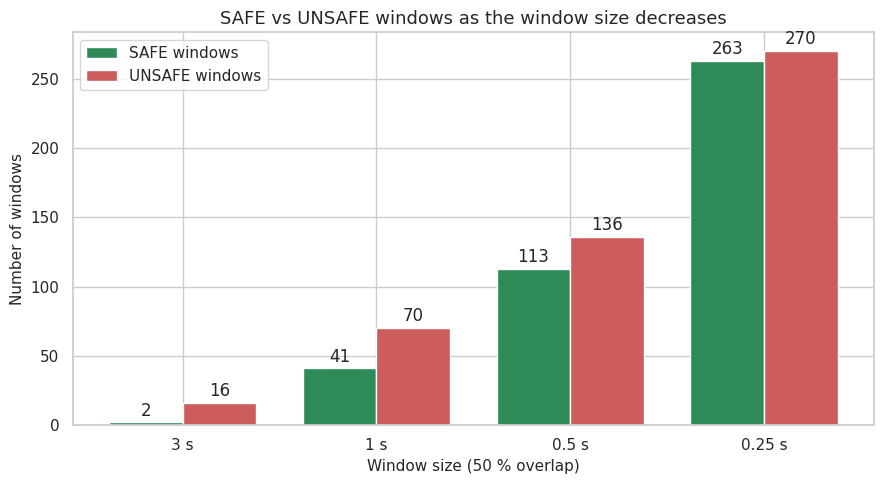

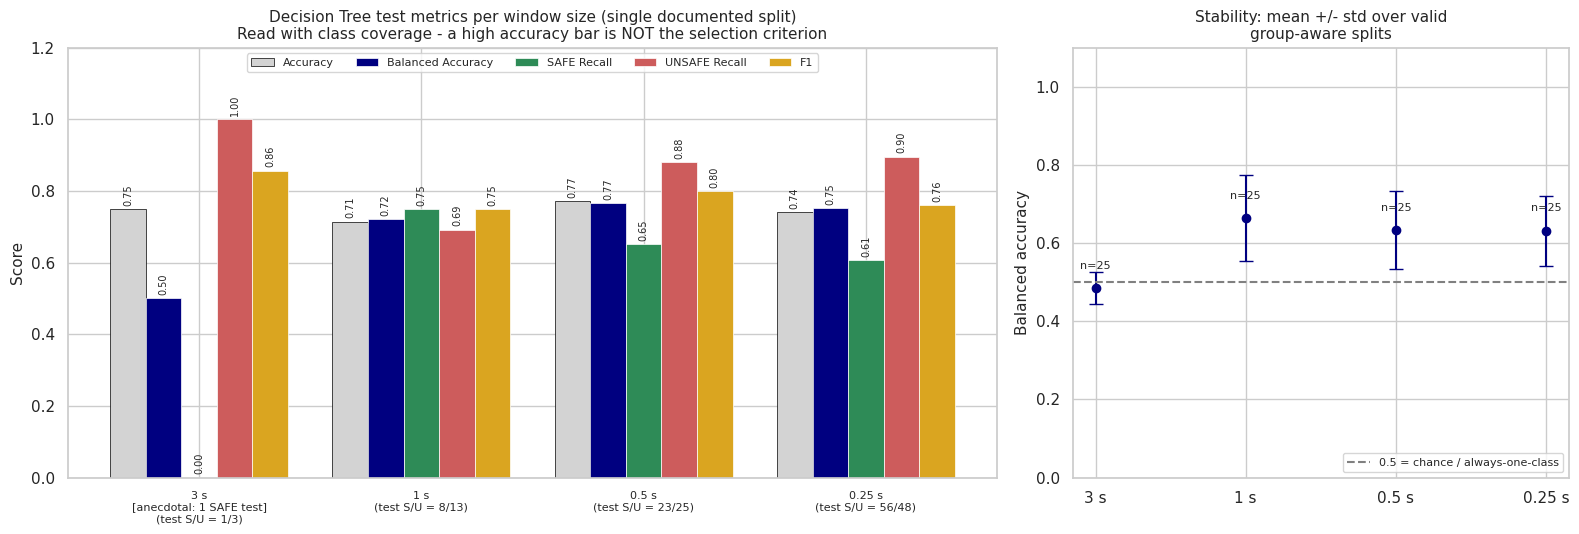

In [12]:
labels_ws = [f"{ws:g} s" for ws in ABLATION_WINDOW_SIZES]
x = np.arange(len(labels_ws)); w = 0.38

# --- Plot 1: class distribution vs window size ---
fig, ax = plt.subplots(figsize=(9, 5))
safe_c = [ablation_results[ws]["n_safe"] for ws in ABLATION_WINDOW_SIZES]
unsafe_c = [ablation_results[ws]["n_unsafe"] for ws in ABLATION_WINDOW_SIZES]
b1 = ax.bar(x - w/2, safe_c, w, color="seagreen", label="SAFE windows")
b2 = ax.bar(x + w/2, unsafe_c, w, color="indianred", label="UNSAFE windows")
ax.bar_label(b1, padding=2); ax.bar_label(b2, padding=2)
ax.set_xticks(x); ax.set_xticklabels(labels_ws)
ax.set_xlabel("Window size (50 % overlap)"); ax.set_ylabel("Number of windows")
ax.set_title("SAFE vs UNSAFE windows as the window size decreases")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "ablation_class_distribution.png", dpi=150); plt.show()

# --- Plot 2: performance comparison (NOT a ranking by accuracy) ---
metric_names = ["Accuracy", "Balanced Accuracy", "SAFE Recall", "UNSAFE Recall", "F1"]
colors = ["lightgrey", "navy", "seagreen", "indianred", "goldenrod"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [3, 1.6]})
ax = axes[0]; bw = 0.16
for j, (mn, c) in enumerate(zip(metric_names, colors)):
    vals = ablation_df[mn].values.astype(float)
    bars = ax.bar(x + (j - 2) * bw, np.nan_to_num(vals, nan=0.0), bw, color=c, label=mn,
                  edgecolor="black" if mn == "Accuracy" else None, linewidth=0.5)
    for xi, v in zip(x + (j - 2) * bw, vals):
        ax.text(xi, (0 if np.isnan(v) else v) + 0.015, "n/a" if np.isnan(v) else f"{v:.2f}", ha="center", fontsize=7, rotation=90)
ticklabels = []
for ws in ABLATION_WINDOW_SIZES:
    r = ablation_results[ws]
    tag = ""
    if r.get("metrics") is None or not r.get("test_both", False): tag = "\n[LIMITED: 1-class test]"
    elif r["test_safe"] < MIN_SAFE_TEST_ADEQUATE: tag = f"\n[anecdotal: {r['test_safe']} SAFE test]"
    ticklabels.append(f"{ws:g} s{tag}\n(test S/U = {r.get('test_safe','-')}/{r.get('test_unsafe','-')})")
ax.set_xticks(x); ax.set_xticklabels(ticklabels, fontsize=8)
ax.set_ylim(0, 1.2); ax.set_ylabel("Score")
ax.set_title("Decision Tree test metrics per window size (single documented split)\n"
             "Read with class coverage - a high accuracy bar is NOT the selection criterion", fontsize=11)
ax.legend(ncol=5, fontsize=8, loc="upper center")

ax = axes[1]
means = ablation_df["Mean Bal.Acc (multi-split)"].values.astype(float)
stds = ablation_df["Std Bal.Acc (multi-split)"].values.astype(float)
nsp = ablation_df["Valid splits"].values
ax.errorbar(x, np.nan_to_num(means, nan=0.0), yerr=np.nan_to_num(stds, nan=0.0), fmt="o", color="navy", capsize=5)
for xi, mu, n in zip(x, means, nsp):
    ax.text(xi, (0 if np.isnan(mu) else mu) + 0.05, "no valid split" if np.isnan(mu) else f"n={n}", ha="center", fontsize=8)
ax.axhline(0.5, color="grey", linestyle="--", label="0.5 = chance / always-one-class")
ax.set_xticks(x); ax.set_xticklabels(labels_ws); ax.set_ylim(0, 1.1)
ax.set_ylabel("Balanced accuracy"); ax.set_title("Stability: mean +/- std over valid\ngroup-aware splits", fontsize=11)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ablation_performance_comparison.png", dpi=150); plt.show()

In [13]:
# ================= FINAL WINDOW SELECTION (documented, rule-based) =================
# Priority (as specified): (1) valid evaluation, (2) trial-aware split with 0 overlap,
# (3) adequate SAFE class coverage, (4) balanced metrics (balanced accuracy over several
# valid splits; SAFE recall / UNSAFE recall / F1 shown alongside), (5) reasonable temporal
# resolution -> among near-equal candidates prefer the LONGER window (more context, less
# noise-sensitivity), (6) reproducibility -> requires several valid splits, and the score is
# the mean over those splits, not one favourable split. Accuracy is NOT used.
SCORE_TOLERANCE = 0.05        # windows within this balanced-accuracy gap are treated as tied
MIN_VALID_SPLITS = 5          # need at least this many valid splits for a stable score

sel = ablation_df.copy()
sel["valid_eval"] = [ablation_results[ws].get("test_both", False) and ablation_results[ws].get("train_both", False)
                     and len(ablation_results[ws].get("overlap", {1})) == 0 for ws in ABLATION_WINDOW_SIZES]
sel["adequate_safe"] = sel["Test SAFE"].fillna(0) >= MIN_SAFE_TEST_ADEQUATE
sel["stable"] = sel["Valid splits"] >= MIN_VALID_SPLITS
sel["ws"] = ABLATION_WINDOW_SIZES

print("Eligibility per window size:")
print(sel[["Window Size", "valid_eval", "adequate_safe", "stable", "Test SAFE", "Valid splits",
           "Mean Bal.Acc (multi-split)"]].to_string(index=False, float_format=lambda v: f"{v:.3f}", na_rep="n/a"))

pool = sel[sel["valid_eval"] & sel["adequate_safe"] & sel["stable"]]
basis = "valid evaluation + adequate SAFE test coverage (>= %d) + >= %d valid splits" % (MIN_SAFE_TEST_ADEQUATE, MIN_VALID_SPLITS)
if pool.empty:
    pool = sel[sel["valid_eval"] & sel["stable"]]
    basis = "valid evaluation + >= %d valid splits (no window reached %d SAFE test windows)" % (MIN_VALID_SPLITS, MIN_SAFE_TEST_ADEQUATE)
if pool.empty:
    pool = sel[sel["valid_eval"]]
    basis = "valid evaluation only (stability across splits could not be established)"

if pool.empty:
    SELECTED_WINDOW_SECONDS = 3.0
    SELECTION_REASON = ("No window size produced a valid two-class evaluation; the original 3.0 s window is kept "
                        "and every result must be treated as limited.")
else:
    best = pool["Mean Bal.Acc (multi-split)"].max()
    tied = pool[pool["Mean Bal.Acc (multi-split)"] >= best - SCORE_TOLERANCE]
    SELECTED_WINDOW_SECONDS = float(tied["ws"].max())     # longest window among near-equal candidates
    SELECTION_REASON = (f"Candidate pool = windows with {basis}. Best mean balanced accuracy in the pool = {best:.3f}; "
                        f"windows within {SCORE_TOLERANCE} of it were treated as tied and the longest tied window "
                        f"was chosen for its larger temporal context.")
print("\nSelection basis :", basis)
print("Selected window :", SELECTED_WINDOW_SECONDS, "s")
print("Reason          :", SELECTION_REASON)

# --- Apply the selection to the main pipeline (Steps 5-15 use WINDOW_SIZE_SECONDS) ---
WINDOW_SIZE_SECONDS = SELECTED_WINDOW_SECONDS
print(f"\nWINDOW_SIZE_SECONDS set to {WINDOW_SIZE_SECONDS} s for Steps 5-15 (trial segmentation unchanged: +/-{SEGMENT_SECONDS} s).")

Eligibility per window size:
Window Size  valid_eval  adequate_safe  stable  Test SAFE  Valid splits  Mean Bal.Acc (multi-split)
        3 s        True          False    True          1            25                       0.485
        1 s        True           True    True          8            25                       0.664
      0.5 s        True           True    True         23            25                       0.633
     0.25 s        True           True    True         56            25                       0.632

Selection basis : valid evaluation + adequate SAFE test coverage (>= 3) + >= 5 valid splits
Selected window : 1.0 s
Reason          : Candidate pool = windows with valid evaluation + adequate SAFE test coverage (>= 3) + >= 5 valid splits. Best mean balanced accuracy in the pool = 0.664; windows within 0.05 of it were treated as tied and the longest tied window was chosen for its larger temporal context.

WINDOW_SIZE_SECONDS set to 1.0 s for Steps 5-15 (trial segment

## Reading the ablation results

The cells above compute everything from the executed experiments; this notebook does not hard-code any result. How to interpret them:

- **Total / SAFE / UNSAFE windows and usable trials** show how much material each window size really gives. The original 3.0 s window discards every trial shorter than 3 s.
- **SAFE windows are still very few and come from a few trials.** Even where a shorter window produces more SAFE windows, they are strongly correlated (50 % overlap, same trial), so the effective number of independent SAFE examples is closer to the number of SAFE-bearing *trials* than to the number of windows.
- **Accuracy is not the criterion.** Predicting UNSAFE for everything already scores highly when most windows are UNSAFE. Balanced accuracy, SAFE recall, UNSAFE recall, F1 and the confusion matrix are read together with the test class counts. A window with a one-class test set is marked *Evaluation limited* and its accuracy is not comparable with a two-class evaluation.
- **Stability.** A single split can look good by chance with so few SAFE windows. The multi-split mean +/- std (valid group-aware splits only, class-coverage criterion only) shows whether a result is robust.
- **Selection** follows the rule printed in the cell above; the selected value is written into `WINDOW_SIZE_SECONDS` and used by Steps 5-15 (so no stale 3.0 s results remain).
- **Interpretation limit.** Whichever window wins, this is a proof-of-concept on a small dataset with no independently recorded SAFE trials; the result is not a general real-world performance estimate.

# Step 5 — Time-Series Windowing

## Purpose
Segment each trial's continuous gyroscope signal into fixed-length, possibly overlapping windows, which will become the unit of feature extraction and classification (Step 6 onward).

## Method
- Window length: `WINDOW_SIZE_SECONDS` - set by the **window-size ablation study** (section above) to the selected value (candidates 3.0, 1.0, 0.5 and 0.25 s).
- Overlap: `WINDOW_OVERLAP` (fraction of the window that overlaps with the next one).
- **Each trial is windowed independently.** A window is only formed from samples belonging to a single `trial_id` — a window is never allowed to span two trials, and any leftover partial window at the end of a trial (shorter than `WINDOW_SIZE_SECONDS`) is discarded rather than padded with foreign data.
- Every window records its `trial_id`, `window_start`, and `window_end` so the mapping back to the source physical trial is always traceable.

## Implementation
`generate_windows()` (defined in the shared helper cell of the ablation section) operates trial-by-trial on `clean_df`, using the actual per-trial sampling rate (derived from `sampling_stats_df` in Step 4) to convert the configured time-based window size/overlap into a sample-count based sliding window.

## Output / Interpretation
`windows_index_df`: one row per window with `trial_id, window_start, window_end, start_idx, end_idx`. A visualization overlays the resulting window boundaries on one representative trial's raw signal.


Total windows generated: 111
trial_id
trial_01    7
trial_02    4
trial_03    5
trial_04    8
trial_05    8
trial_06    6
trial_07    6
trial_08    5
trial_09    4
trial_10    7
trial_11    7
trial_12    5
trial_13    6
trial_14    5
trial_15    5
trial_16    4
trial_17    5
trial_18    6
trial_19    6
trial_20    2
Name: n_windows, dtype: int64


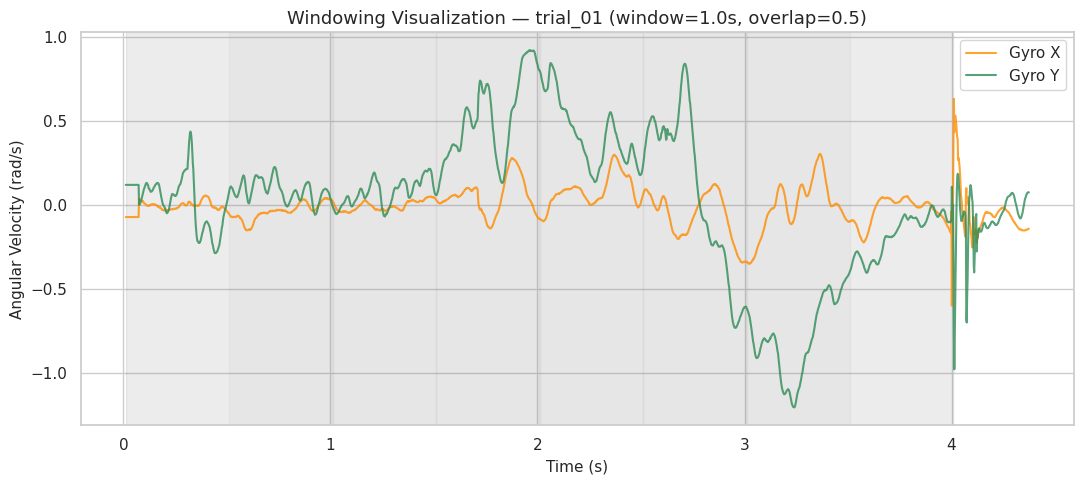

In [14]:
# generate_windows() is defined once in the shared helper cell of the window-size ablation
# section (above), so the ablation and Steps 5-15 use the identical windowing code.

windows_index_df = generate_windows(clean_df, WINDOW_SIZE_SECONDS, WINDOW_OVERLAP)

print(f"Total windows generated: {len(windows_index_df)}")
if not windows_index_df.empty:
    print(windows_index_df.groupby("trial_id").size().rename("n_windows"))
else:
    print("No windows generated yet — check that dataset/raw/Raw Data.csv is present and covers the configured EVENT_TIMES.")

# ---------------------------------------------------------------
# Visualization: windowing overlay on a representative trial
# ---------------------------------------------------------------
if not clean_df.empty and not windows_index_df.empty:
    representative_trial = sorted(clean_df["trial_id"].unique())[0]
    trial_data = clean_df[clean_df["trial_id"] == representative_trial].sort_values("timestamp").reset_index(drop=True)
    trial_windows = windows_index_df[windows_index_df["trial_id"] == representative_trial]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(trial_data["timestamp"], trial_data["gyro_x"], color="darkorange", label="Gyro X", alpha=0.8)
    ax.plot(trial_data["timestamp"], trial_data["gyro_y"], color="seagreen", label="Gyro Y", alpha=0.8)

    for i, (_, w) in enumerate(trial_windows.iterrows()):
        ax.axvspan(w["window_start"], w["window_end"],
                   color="grey", alpha=0.15 if i % 2 == 0 else 0.05)

    ax.set_title(f"Windowing Visualization — {representative_trial} "
                 f"(window={WINDOW_SIZE_SECONDS}s, overlap={WINDOW_OVERLAP})")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity (rad/s)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "windowing_visualization.png", dpi=150)
    plt.show()
else:
    print("Windowing visualization skipped — no data available yet.")

# Step 6 — Feature Extraction (from X and Y)

## Purpose
Convert each raw window of gyroscope samples into a fixed-length numerical feature vector, using **only** gyroscope X and Y.

## Method
For each window, the **primary six-feature vector** (matching the workflow specification) is:

$$[\ \bar{X},\ \sigma_X,\ \mathrm{RMS}_X,\ \bar{Y},\ \sigma_Y,\ \mathrm{RMS}_Y\ ]$$

where RMS is defined as:

$$\mathrm{RMS}(v) = \sqrt{\mathrm{mean}(v^2)}$$

As an **optional, clearly-separated supplementary** set (not part of the primary Decision Tree input), the combined in-plane magnitude is also summarised:

$$\omega_{xy} = \sqrt{X^2 + Y^2} \quad\rightarrow\quad \bar{\omega}_{xy},\ \sigma_{\omega_{xy}},\ \mathrm{RMS}_{\omega_{xy}}$$

Z is never used in any of the above.

## Implementation
`extract_features_from_window()` is a reusable function taking a window's X and Y arrays and returning a dictionary of the six primary features (plus the three optional `omega_xy` features, stored separately). It is applied to every row of `windows_index_df` against the corresponding samples in `clean_df`.

## Output / Interpretation
`features_df`: one row per window with the six primary features (`X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms`), the three optional `omega_xy` statistics, and the traceability columns `trial_id, window_start, window_end`. This becomes the direct input to Step 7 (Feature Matrix).


In [15]:
# rms() and extract_features_from_window() are defined in the shared helper cell of the
# window-size ablation section (above).

feature_rows = []
for tid, g in clean_df.groupby("trial_id"):
    g = g.sort_values("timestamp").reset_index(drop=True)
    trial_windows = windows_index_df[windows_index_df["trial_id"] == tid]

    for _, w in trial_windows.iterrows():
        window_slice = g.iloc[w["start_idx"]:w["end_idx"]]
        feats = extract_features_from_window(window_slice["gyro_x"].values,
                                              window_slice["gyro_y"].values)
        feats.update({
            "trial_id": tid,
            "window_start": w["window_start"],
            "window_end": w["window_end"],
        })
        feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)

PRIMARY_FEATURE_COLS = ["X_mean", "X_std", "X_rms", "Y_mean", "Y_std", "Y_rms"]
SUPPLEMENTARY_FEATURE_COLS = ["omega_xy_mean", "omega_xy_std", "omega_xy_rms"]

print(f"Total feature windows extracted: {len(features_df)}")
if not features_df.empty:
    ordered_cols = ["trial_id", "window_start", "window_end"] + PRIMARY_FEATURE_COLS + SUPPLEMENTARY_FEATURE_COLS
    features_df = features_df[ordered_cols]
    print(features_df.head())
else:
    print("Not available until data is provided.")

Total feature windows extracted: 111
   trial_id  window_start  window_end    X_mean     X_std     X_rms    Y_mean     Y_std     Y_rms  omega_xy_mean  omega_xy_std  omega_xy_rms
0  trial_01      0.011484    1.009286 -0.026184  0.043285  0.050588  0.053026  0.122677  0.133646       0.123214      0.072378      0.142900
1  trial_01      0.511418    1.509194 -0.022609  0.043366  0.048906  0.079315  0.069479  0.105443       0.102651      0.054523      0.116232
2  trial_01      1.011285    2.009119  0.023564  0.082799  0.086087  0.294397  0.286206  0.410589       0.311711      0.280768      0.419517
3  trial_01      1.511193    2.509278  0.067422  0.100977  0.121417  0.471057  0.228472  0.523539       0.486794      0.227744      0.537434
4  trial_01      2.011118    3.009550  0.008249  0.138508  0.138754  0.256218  0.398977  0.474163       0.448209      0.207826      0.494047


# Step 7 — Feature Matrix (X)

## Purpose
Assemble the primary six-column feature matrix that will be fed to the Decision Tree (and, later, the tiny Keras model), and inspect its statistical properties before modelling.

## Method
- Select the primary columns `[X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms]` from `features_df`.
- Display shape, head, and descriptive statistics.
- Visualise feature distributions (histograms + box plots) and inter-feature correlation.

## Implementation
Purely structural/inspection code — no values are invented; if `features_df` is empty, shapes/statistics correctly report zero rows and the plots are skipped with a clear message.

## Output / Interpretation
`X_matrix`: the `(n_windows, 6)` feature matrix used for the primary Decision Tree classifier. The distribution and correlation plots help sanity-check the feature engineering before training (e.g. checking for near-duplicate or degenerate features).


Feature matrix shape: (111, 6)

First rows:
     X_mean     X_std     X_rms    Y_mean     Y_std     Y_rms
0 -0.026184  0.043285  0.050588  0.053026  0.122677  0.133646
1 -0.022609  0.043366  0.048906  0.079315  0.069479  0.105443
2  0.023564  0.082799  0.086087  0.294397  0.286206  0.410589
3  0.067422  0.100977  0.121417  0.471057  0.228472  0.523539
4  0.008249  0.138508  0.138754  0.256218  0.398977  0.474163

Descriptive statistics:
           X_mean       X_std       X_rms      Y_mean       Y_std       Y_rms
count  111.000000  111.000000  111.000000  111.000000  111.000000  111.000000
mean     0.011993    0.488089    0.597159    0.004261    0.473201    0.562686
std      0.406193    0.391756    0.446281    0.380828    0.483182    0.533830
min     -1.101164    0.043285    0.048906   -1.252044    0.066725    0.084212
25%     -0.197630    0.205276    0.270207   -0.151092    0.185968    0.197023
50%      0.021691    0.336225    0.427564   -0.002756    0.308071    0.385851
75%      0.21

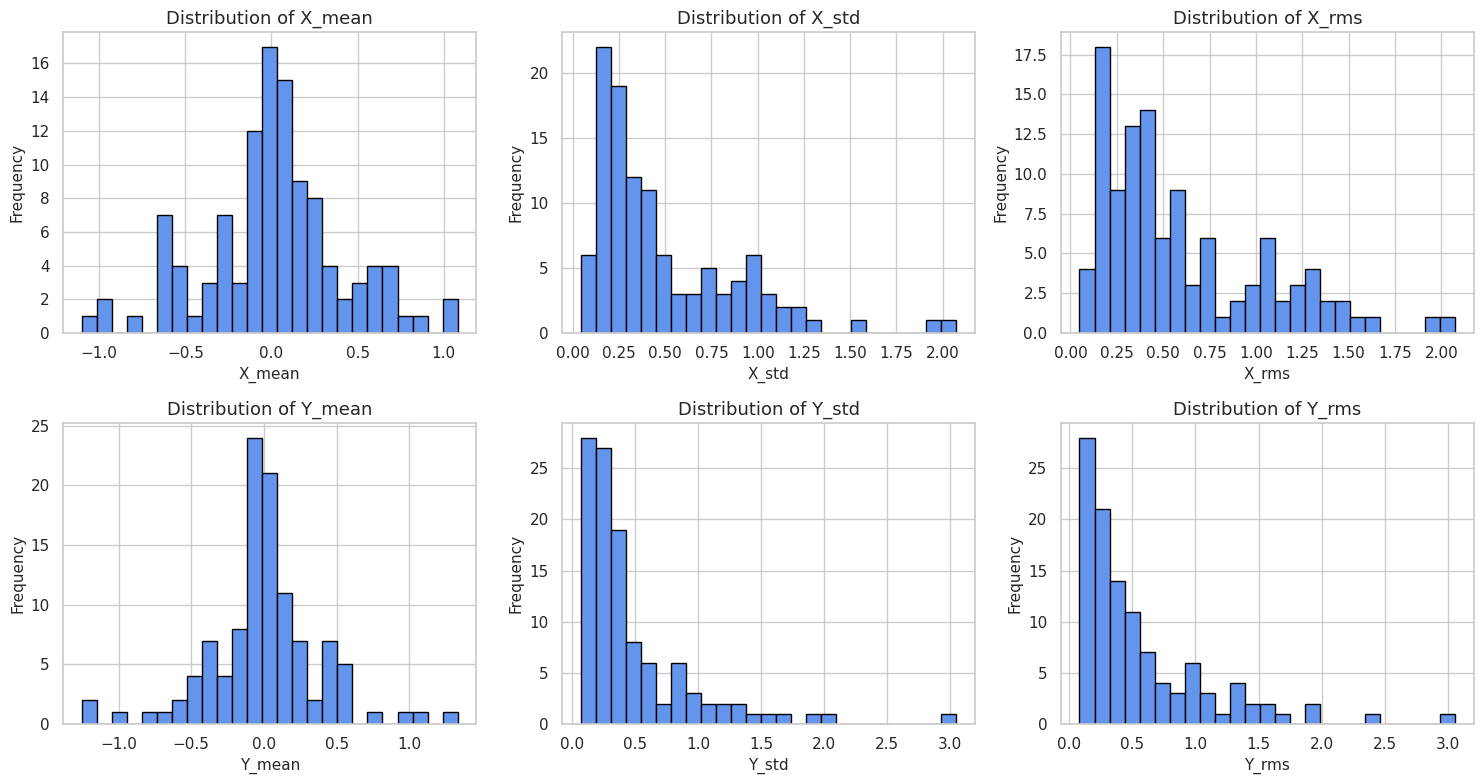

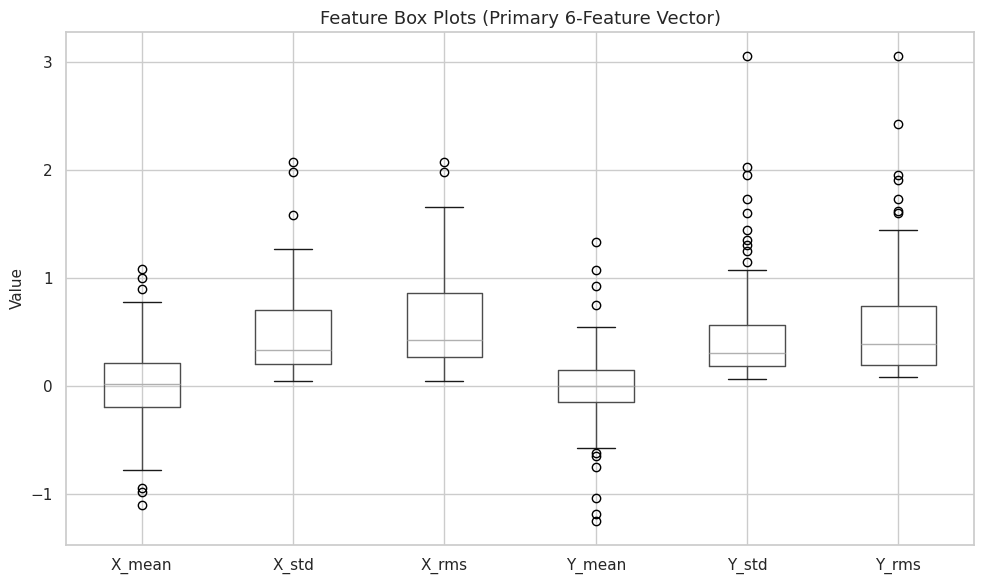

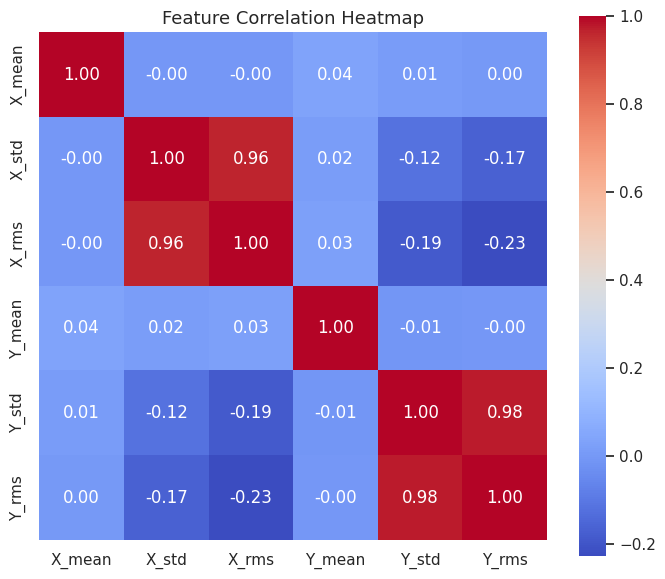

In [16]:
X_matrix = features_df[PRIMARY_FEATURE_COLS].copy() if not features_df.empty else pd.DataFrame(columns=PRIMARY_FEATURE_COLS)

print("Feature matrix shape:", X_matrix.shape)
print("\nFirst rows:")
print(X_matrix.head())

print("\nDescriptive statistics:")
print(X_matrix.describe() if not X_matrix.empty else "Not available until data is provided.")

if not X_matrix.empty:
    # --- Feature distributions (histograms) ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, col in zip(axes.ravel(), PRIMARY_FEATURE_COLS):
        ax.hist(X_matrix[col], bins=25, color="cornflowerblue", edgecolor="black")
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_distributions.png", dpi=150)
    plt.show()

    # --- Box plots ---
    fig, ax = plt.subplots(figsize=(10, 6))
    X_matrix.boxplot(column=PRIMARY_FEATURE_COLS, ax=ax)
    ax.set_title("Feature Box Plots (Primary 6-Feature Vector)")
    ax.set_ylabel("Value")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_boxplots.png", dpi=150)
    plt.show()

    # --- Correlation heatmap ---
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(X_matrix.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
    ax.set_title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_correlation_heatmap.png", dpi=150)
    plt.show()
else:
    print("Feature plots skipped — no data available yet.")

# Step 8 — Labels (y)

## Purpose
Assign a `SAFE (0)` / `UNSAFE (1)` label to every window, derived strictly from the trial-level metadata — never fabricated or assumed.

## Method (labelling rule — documented explicitly to avoid ambiguity/leakage)
- If a trial's metadata label is **SAFE (0)**: every window belonging to that trial is labelled `0`.
- If a trial's metadata label is **UNSAFE (1)**:
  - If `failure_time` is **not available**, every window in that trial is conservatively labelled `1` (the whole trial is treated as unsafe, since no finer-grained timing information exists).
  - If `failure_time` **is available**, windows are split within the trial:
    - A window whose `window_end <= failure_time` is labelled `0` (SAFE — occurs entirely before the instability event).
    - A window whose `window_start >= failure_time` is labelled `1` (UNSAFE — occurs entirely after onset).
    - A window that **straddles** `failure_time` (i.e. `window_start < failure_time < window_end`) is labelled `1`, since it contains the onset of instability and including it as SAFE would leak post-failure dynamics into the SAFE class.
- This rule is applied per-window, not per-trial, for UNSAFE trials with a known `failure_time` — it deliberately avoids the naive shortcut of labelling every window in an UNSAFE trial as `1` regardless of timing.

## Implementation
`assign_labels()` implements exactly the rule above and is applied per-window using `metadata_df`.

## Output / Interpretation
`y_labels`: a per-window label aligned with `features_df`/`X_matrix`. Class counts, percentages, and a class-distribution plot follow — all computed from real data only.

## Important: what SAFE means in this dataset
- **SAFE does not mean that an independently recorded trial was physically safe.** All 20 trials contain a fall, so every trial-level label is UNSAFE (`label = 1`).
- SAFE (`0`) exists only at the **window level**: a window (of the selected `WINDOW_SIZE_SECONDS`) that ends at or before the recorded failure event in a failure trial.
- The experiment therefore demonstrates **pre-failure vs failure-window** detection. It cannot show that the model separates genuinely safe trials from unsafe ones.
- The data-quality message `No SAFE (label=0) trials found in metadata` printed after labelling is **expected** for this reason. It is a true statement about the dataset, not a bug.
- Label values stay `SAFE = 0`, `UNSAFE = 1` (constants defined in the Configuration cell).


=== Class Counts ===
            count  percentage
label                        
SAFE (0)       41       36.94
UNSAFE (1)     70       63.06


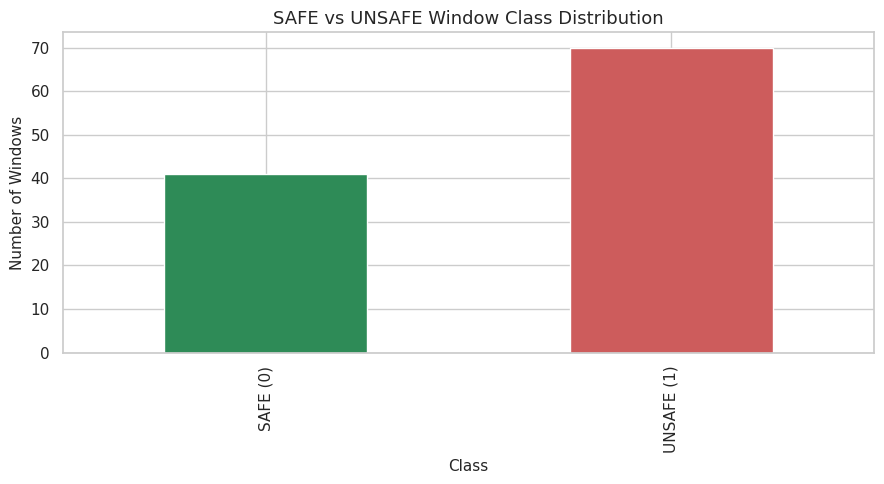


=== Data Quality Report [post-labelling] ===
  [ISSUE] No SAFE (label=0) trials found in metadata.
  Rows checked: 34761, Trials checked: 20


In [17]:
# assign_labels() is defined in the shared helper cell of the window-size ablation
# section (above). Labelling rule unchanged.

y_labels, label_trace_df = assign_labels(features_df, metadata_df)

if not features_df.empty:
    features_df["label"] = y_labels
    # Drop any windows whose trial had no metadata match (label is NA)
    unlabelled = features_df["label"].isna().sum()
    if unlabelled > 0:
        print(f"[WARNING] {unlabelled} window(s) dropped — no matching metadata entry.")
    features_df = features_df.dropna(subset=["label"]).reset_index(drop=True)
    features_df["label"] = features_df["label"].astype(int)
    X_matrix = features_df[PRIMARY_FEATURE_COLS].copy()
    y_labels = features_df["label"].copy()

print("\n=== Class Counts ===")
if not features_df.empty:
    counts = y_labels.value_counts().sort_index()
    percentages = (counts / counts.sum() * 100).round(2)
    class_summary_df = pd.DataFrame({"count": counts, "percentage": percentages})
    class_summary_df.index = class_summary_df.index.map({0: "SAFE (0)", 1: "UNSAFE (1)"})
    print(class_summary_df)

    fig, ax = plt.subplots()
    class_summary_df["count"].plot(kind="bar", ax=ax, color=["seagreen", "indianred"])
    ax.set_title("SAFE vs UNSAFE Window Class Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Windows")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150)
    plt.show()
else:
    print("Not available until data is provided.")

run_quality_checks(clean_df, metadata_df, stage="post-labelling")

# Step 9 — Train/Test Split

## Purpose
Split the windowed feature dataset into training and testing sets (about 80/20) so that the evaluation is **leakage-free** and, where the data allow it, **covers both classes in the test set**.

## Why the split must be trial (group) aware
Windows overlap by 50 %, so two consecutive windows from the same trial share half of their samples. A plain `train_test_split(X, y)` on windows would put near-duplicate windows of one physical trial into both train and test and inflate every metric. The split therefore uses `GroupShuffleSplit` with `groups = trial_id`: every window of a trial falls entirely in train **or** entirely in test.

## Why class coverage of the test set is checked
Only a handful of trials contain SAFE windows (see the class diagnostics below), and each trial contributes its windows as a block. A purely random trial-level split can put all SAFE-bearing trials in train, leaving a test set with only UNSAFE windows. A test set with one class cannot evaluate SAFE-vs-UNSAFE discrimination (no false alarm can occur, and precision becomes trivially 1.0).

## Method (minimum change to the original split)
1. Try group-aware splits from seed `RANDOM_STATE` upward (`GroupShuffleSplit`, `test_size = TEST_SIZE`).
2. Use the **first** split in which both train and test contain both classes. The selection looks only at which classes are present, never at model scores, so it is not tuning for a better-looking accuracy.
3. No window is duplicated, no SMOTE is used, no sensor data are altered, and no trial is invented.
4. If no such split exists, keep the original-seed group split and print an explicit warning.
5. Verify that no trial is in both sets and that no train window overlaps a test window in time.

## Output
`X_train, X_test, y_train, y_test`, `train_trials`, `test_trials`, `split_seed_used` and the flags `train_has_both_classes` / `test_has_both_classes`. The next cell reports the class distributions.

In [18]:
def class_counts(y):
    y = pd.Series(y)
    return int((y == SAFE).sum()), int((y == UNSAFE).sum())


if features_df.empty:
    print("Train/test split not available until data is provided.")
    X_train = X_test = pd.DataFrame(columns=PRIMARY_FEATURE_COLS)
    y_train = y_test = pd.Series(dtype=int)
    train_trials = test_trials = []
    split_seed_used = None
    train_has_both_classes = test_has_both_classes = False
else:
    groups = features_df["trial_id"].values
    n_trials_total = features_df["trial_id"].nunique()

    chosen = None
    for k in range(SPLIT_SEARCH_MAX_SEEDS):
        seed = RANDOM_STATE + k
        splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
        tr_i, te_i = next(splitter.split(X_matrix, y_labels, groups=groups))
        if y_labels.iloc[tr_i].nunique() == 2 and y_labels.iloc[te_i].nunique() == 2:
            chosen = (seed, tr_i, te_i, k + 1)
            break

    if chosen is not None:
        split_seed_used, train_idx, test_idx, n_attempts = chosen
        print(f"Group-aware split with both classes in train AND test found at seed "
              f"{split_seed_used} (attempt {n_attempts}).")
    else:
        split_seed_used = RANDOM_STATE
        splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=split_seed_used)
        train_idx, test_idx = next(splitter.split(X_matrix, y_labels, groups=groups))
        print(f"[WARNING] No group-aware split with both classes in train and test exists within "
              f"{SPLIT_SEARCH_MAX_SEEDS} seeds. Falling back to the original seed {RANDOM_STATE}. "
              f"Test-set class coverage must be checked before reporting metrics.")

    X_train, X_test = X_matrix.iloc[train_idx], X_matrix.iloc[test_idx]
    y_train, y_test = y_labels.iloc[train_idx], y_labels.iloc[test_idx]

    train_trials = sorted(features_df.iloc[train_idx]["trial_id"].unique().tolist())
    test_trials = sorted(features_df.iloc[test_idx]["trial_id"].unique().tolist())
    train_has_both_classes = y_train.nunique() == 2
    test_has_both_classes = y_test.nunique() == 2

    # --- Leakage check 1: no trial in both splits ---
    overlap = set(train_trials) & set(test_trials)
    if overlap:
        print(f"[ERROR] Trial leakage detected between train and test: {overlap}")
    else:
        print("No trial appears in both train and test - confirmed.")

    # --- Leakage check 2: no train window overlaps a test window in time ---
    tr_w = features_df.iloc[train_idx][["trial_id", "window_start", "window_end"]]
    te_w = features_df.iloc[test_idx][["trial_id", "window_start", "window_end"]]
    n_time_overlaps = sum(
        int((tr_w["window_start"] < r.window_end).__and__(tr_w["window_end"] > r.window_start).sum())
        for r in te_w.itertuples()
    )
    print(f"Train/test windows overlapping in time: {n_time_overlaps} "
          f"({'OK' if n_time_overlaps == 0 else 'LEAKAGE - investigate'})")

    print(f"\nTraining trials ({len(train_trials)}): {train_trials}")
    print(f"Testing trials  ({len(test_trials)}): {test_trials}")

Group-aware split with both classes in train AND test found at seed 42 (attempt 1).
No trial appears in both train and test - confirmed.
Train/test windows overlapping in time: 0 (OK)

Training trials (16): ['trial_03', 'trial_04', 'trial_05', 'trial_06', 'trial_07', 'trial_08', 'trial_09', 'trial_10', 'trial_11', 'trial_12', 'trial_13', 'trial_14', 'trial_15', 'trial_17', 'trial_19', 'trial_20']
Testing trials  (4): ['trial_01', 'trial_02', 'trial_16', 'trial_18']


## Class-Distribution Diagnostics (run before training any model)

This section shows exactly which classes each split contains, **before** any model is trained, so it is obvious whether the evaluation is meaningful. It prints the overall, training and test window counts, the number of trials per split, and which trials supply the SAFE windows. Because SAFE windows exist only inside failure trials, the number of trials that carry SAFE windows limits what any split can achieve.

CLASS-DISTRIBUTION DIAGNOSTICS
Overall windows:
   SAFE   (0) =  41   ( 36.9 %)
   UNSAFE (1) =  70   ( 63.1 %)
   Trials with windows: 20 (of 20 recorded trials; the rest are too short to hold a full 1 s window)

Split used: group-aware GroupShuffleSplit, seed = 42
Training trials: 16   Testing trials: 4

Training windows (90):
   SAFE   (0) =  33   ( 36.7 %)
   UNSAFE (1) =  57   ( 63.3 %)

Testing windows (21):
   SAFE   (0) =   8   ( 38.1 %)
   UNSAFE (1) =  13   ( 61.9 %)

Per-trial window counts and split assignment:
          SAFE_windows  UNSAFE_windows  split
trial_id                                     
trial_01             4               3   test
trial_02             1               3   test
trial_03             1               4  train
trial_04             2               6  train
trial_05             5               3  train
trial_06             2               4  train
trial_07             2               4  train
trial_08             2               3  train
trial_09   

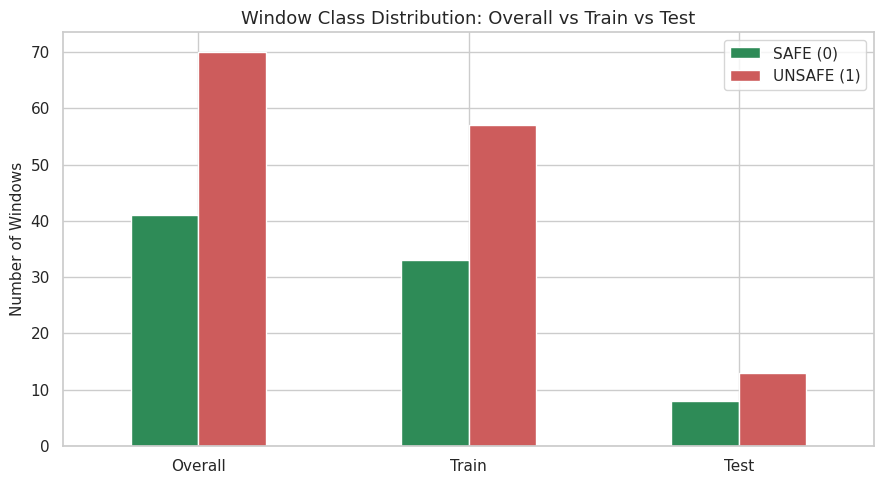

In [19]:
def show_distribution(title, y):
    n_s, n_u = class_counts(y)
    n = n_s + n_u
    pct_s = 100 * n_s / n if n else float("nan")
    pct_u = 100 * n_u / n if n else float("nan")
    print(f"{title}")
    print(f"   SAFE   (0) = {n_s:3d}   ({pct_s:5.1f} %)")
    print(f"   UNSAFE (1) = {n_u:3d}   ({pct_u:5.1f} %)")


if features_df.empty:
    print("Diagnostics not available until data is provided.")
else:
    print("=" * 62)
    print("CLASS-DISTRIBUTION DIAGNOSTICS")
    print("=" * 62)
    show_distribution("Overall windows:", y_labels)
    print(f"   Trials with windows: {features_df['trial_id'].nunique()} "
          f"(of {master_df['trial_id'].nunique()} recorded trials; the rest are too short "
          f"to hold a full {WINDOW_SIZE_SECONDS:g} s window)")

    print(f"\nSplit used: group-aware GroupShuffleSplit, seed = {split_seed_used}")
    print(f"Training trials: {len(train_trials)}   Testing trials: {len(test_trials)}")
    print()
    show_distribution(f"Training windows ({len(y_train)}):", y_train)
    print()
    show_distribution(f"Testing windows ({len(y_test)}):", y_test)

    # --- Which trials carry SAFE windows, and where did they go? ---
    per_trial = (features_df.groupby("trial_id")["label"]
                 .agg(SAFE_windows=lambda s: int((s == SAFE).sum()),
                      UNSAFE_windows=lambda s: int((s == UNSAFE).sum())))
    per_trial["split"] = ["train" if t in train_trials else "test" for t in per_trial.index]
    print("\nPer-trial window counts and split assignment:")
    print(per_trial.to_string())

    safe_trials = per_trial.index[per_trial["SAFE_windows"] > 0].tolist()
    print(f"\nTrials that contain SAFE windows: {safe_trials} "
          f"({len(safe_trials)} trial(s))")

    # --- Evaluation-validity warnings ---
    print("\n" + "-" * 62)
    print("DATASET LIMITATION:")
    print("  The dataset contains no independently recorded SAFE trials.")
    print("  SAFE windows are generated only from pre-failure windows inside failure trials,")
    print("  so this experiment is pre-failure vs failure-window classification, not")
    print("  general SAFE-trial vs UNSAFE-trial classification.")

    if len(safe_trials) < 2:
        print("\n[WARNING] Fewer than 2 trials contain SAFE windows, so a trial-aware split cannot")
        print("  place SAFE windows in both train and test.")
    if not test_has_both_classes:
        print("\n[WARNING] Test set contains only one class.")
        print("  Binary SAFE-vs-UNSAFE evaluation is limited: no false alarm can occur and precision is")
        print("  trivially 1.0 when UNSAFE is the only class. Do not read the metrics as discrimination.")
    if not train_has_both_classes:
        print("\n[WARNING] Training set contains only one class: models cannot learn SAFE vs UNSAFE.")
    n_safe_test, _ = class_counts(y_test)
    n_safe_train, _ = class_counts(y_train)
    if test_has_both_classes and train_has_both_classes:
        print("\n[OK] Both classes are present in train and in test.")
        print(f"[CAUTION] Support is tiny: SAFE train = {n_safe_train}, SAFE test = {n_safe_test}. "
              f"SAFE-class metrics rest on {n_safe_test} test window(s) and are anecdotal, "
              f"not statistically reliable.")
    print("-" * 62)

    # --- Plot ---
    dist_df = pd.DataFrame({
        "Overall": class_counts(y_labels),
        "Train": class_counts(y_train),
        "Test": class_counts(y_test),
    }, index=["SAFE (0)", "UNSAFE (1)"]).T
    fig, ax = plt.subplots()
    dist_df.plot(kind="bar", ax=ax, color=["seagreen", "indianred"], rot=0)
    ax.set_title("Window Class Distribution: Overall vs Train vs Test")
    ax.set_ylabel("Number of Windows")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "split_class_distribution.png", dpi=150)
    plt.show()

In [20]:
# --- Consistency check: the main pipeline (Steps 5-9) must reproduce the ablation record
#     of the selected window exactly (guards against stale results from another window size) ---
_r = ablation_results[SELECTED_WINDOW_SECONDS]
assert WINDOW_SIZE_SECONDS == SELECTED_WINDOW_SECONDS
assert len(features_df) == _r["n_windows"], (len(features_df), _r["n_windows"])
assert class_counts(y_labels) == (_r["n_safe"], _r["n_unsafe"])
assert split_seed_used == _r["seed"], (split_seed_used, _r["seed"])
assert train_trials == _r["train_trials"] and test_trials == _r["test_trials"]
assert len(set(train_trials) & set(test_trials)) == 0
print(f"[CHECK PASSED] Main pipeline matches ablation record for {SELECTED_WINDOW_SECONDS:g} s: "
      f"{len(features_df)} windows, seed {split_seed_used}, {len(train_trials)} train / {len(test_trials)} test trials, 0 overlapping trials.")
print(f"Train SAFE/UNSAFE = {class_counts(y_train)}, Test SAFE/UNSAFE = {class_counts(y_test)}")

[CHECK PASSED] Main pipeline matches ablation record for 1 s: 111 windows, seed 42, 16 train / 4 test trials, 0 overlapping trials.
Train SAFE/UNSAFE = (33, 57), Test SAFE/UNSAFE = (8, 13)


# Step 10 — Lightweight Classifier (Decision Tree)

## Purpose
Train the **primary lightweight classifier** specified by the workflow: a scikit-learn `DecisionTreeClassifier`, using only the training split from Step 9.

## Method
- `DecisionTreeClassifier(max_depth=DT_MAX_DEPTH, random_state=RANDOM_STATE)`.
- Trained exclusively on `X_train`/`y_train` — the test set is never seen during training.
- After training: report the tree's depth, number of leaves, number of internal nodes, and (optionally) a visualisation of the tree structure.

## Implementation
Straightforward `sklearn` fit call plus structural introspection (`tree_.max_depth`, `tree_.n_leaves`, `tree_.node_count`).

## Output / Interpretation
`dt_model`: the trained Decision Tree. This is the model formally evaluated in Step 11 as the primary lightweight classical classifier. It is **not** the model used for TFLite conversion (see the design-decision note immediately below).


Decision Tree trained.
Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Actual tree depth   : 5
Number of leaves    : 10
Number of nodes     : 19


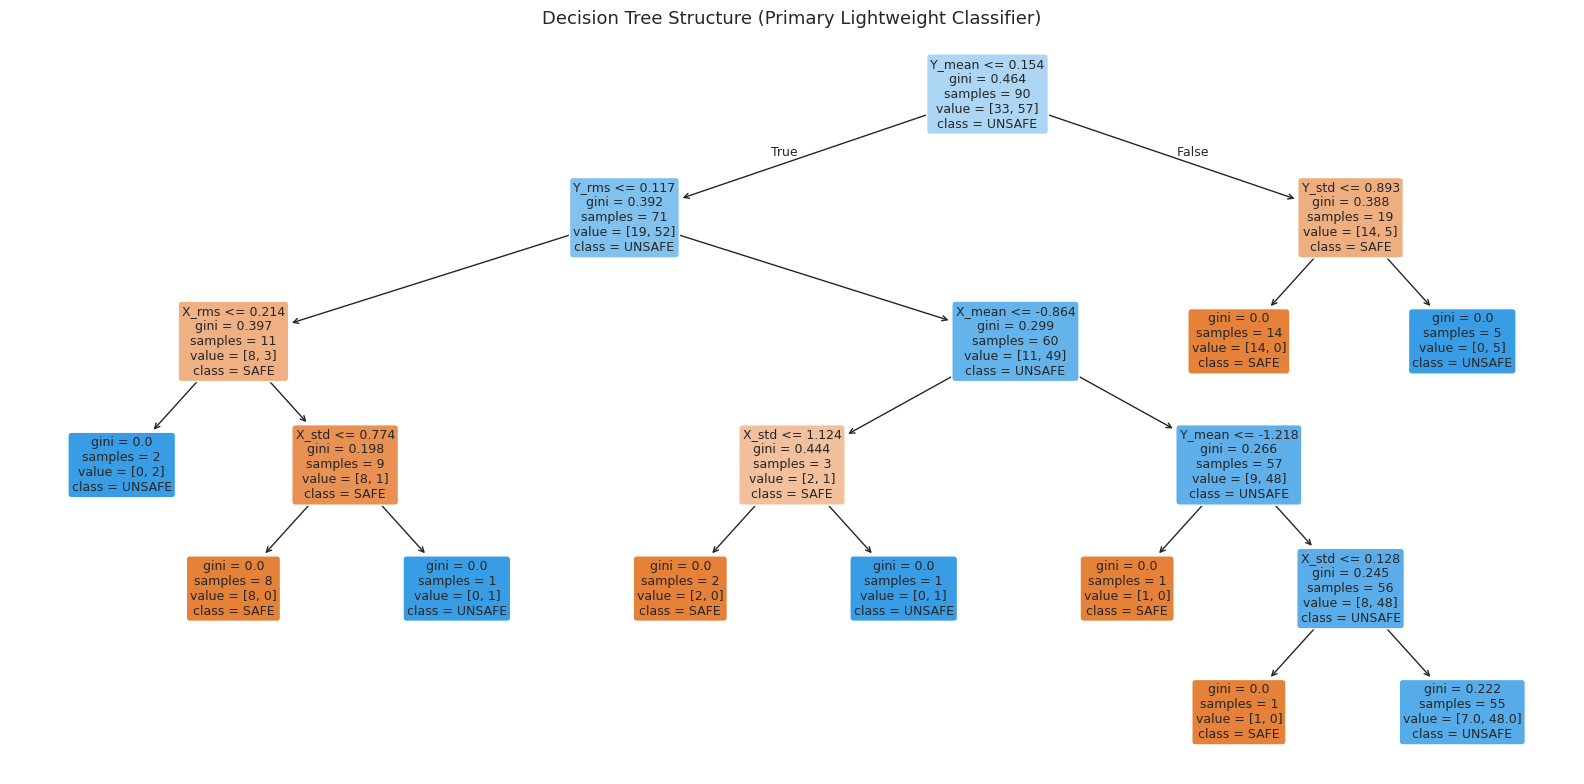

In [21]:
if len(X_train) == 0:
    print("Decision Tree training skipped — no training data available yet.")
    dt_model = None
else:
    dt_model = DecisionTreeClassifier(max_depth=DT_MAX_DEPTH, random_state=RANDOM_STATE)
    dt_model.fit(X_train, y_train)

    print("Decision Tree trained.")
    print("Parameters:", dt_model.get_params())
    print(f"\nActual tree depth   : {dt_model.tree_.max_depth}")
    print(f"Number of leaves    : {dt_model.tree_.n_leaves}")
    print(f"Number of nodes     : {dt_model.tree_.node_count}")

    fig, ax = plt.subplots(figsize=(16, 8))
    plot_tree(dt_model, feature_names=PRIMARY_FEATURE_COLS,
              class_names=["SAFE", "UNSAFE"], filled=True, rounded=True, fontsize=9, ax=ax)
    ax.set_title("Decision Tree Structure (Primary Lightweight Classifier)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "decision_tree_structure.png", dpi=150)
    plt.show()

# Step 11 — Model Evaluation

## Purpose
Evaluate the trained Decision Tree on the **held-out test set only**, using standard classification metrics, and visualise the confusion matrix and feature importances.

## Method
- Compute Accuracy, Precision, Recall, and F1-score (`sklearn.metrics`).
- Compute and visualise the confusion matrix as a heatmap, with **TP / TN / FP / FN** explicitly labelled and explained:
  - **TP (True Positive):** correctly predicted UNSAFE.
  - **TN (True Negative):** correctly predicted SAFE.
  - **FP (False Positive):** predicted UNSAFE when actually SAFE (false alarm).
  - **FN (False Negative):** predicted SAFE when actually UNSAFE (missed instability — the more safety-critical error type).
- Print the full `sklearn` classification report.
- Plot feature importances from the trained tree.

## Implementation
All metrics/plots are computed only from `dt_model.predict(X_test)` vs `y_test` — nothing here is hypothetical or precomputed.

## Output / Interpretation
A complete, real evaluation of the Decision Tree once real data has been supplied and the notebook executed. Until then, this cell explicitly reports that no evaluation is available rather than inventing numbers.


=== Decision Tree - Test Set Performance ===
Test support: SAFE = 8, UNSAFE = 13
Accuracy : 0.7143
Precision: 0.8182   (UNSAFE = positive class)
Recall   : 0.6923   (UNSAFE recall)
F1-score : 0.7500
SAFE recall (true-negative rate): 0.7500
Balanced accuracy               : 0.7212

Classification report:
              precision    recall  f1-score   support

    SAFE (0)       0.60      0.75      0.67         8
  UNSAFE (1)       0.82      0.69      0.75        13

    accuracy                           0.71        21
   macro avg       0.71      0.72      0.71        21
weighted avg       0.74      0.71      0.72        21

Confusion Matrix layout:
            Pred SAFE   Pred UNSAFE
True SAFE      TN=6        FP=2
True UNSAFE    FN=4        TP=9


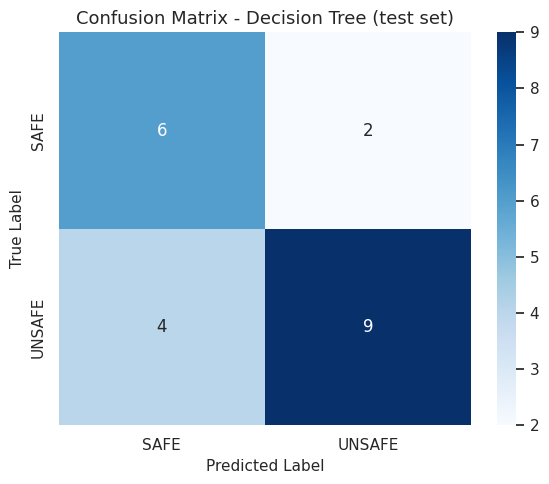

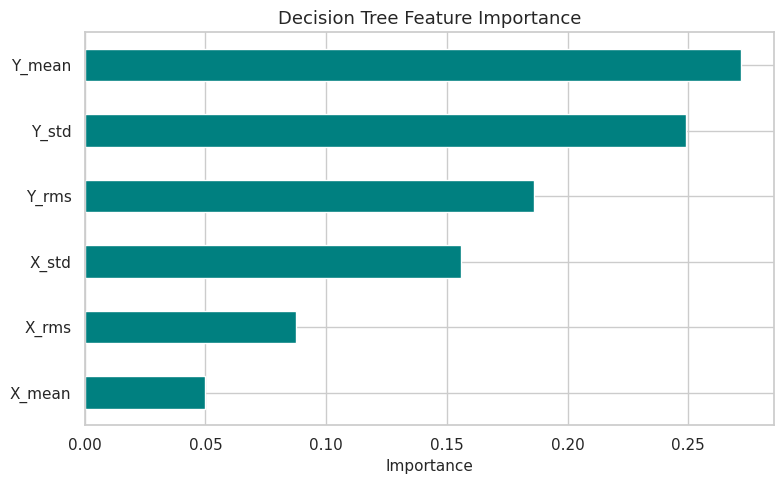

In [22]:
def evaluate_binary(name, y_true, y_pred, show_report=True):
    """Evaluate binary SAFE(0)/UNSAFE(1) predictions honestly: explicit class-coverage
    check, zero_division=0, fixed label order, and per-class recalls."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    n_safe, n_unsafe = int((y_true == SAFE).sum()), int((y_true == UNSAFE).sum())
    both = n_safe > 0 and n_unsafe > 0

    print(f"=== {name} - Test Set Performance ===")
    print(f"Test support: SAFE = {n_safe}, UNSAFE = {n_unsafe}")
    if not both:
        print("WARNING: Test set contains only one class.")
        print("Binary SAFE-vs-UNSAFE evaluation is limited. Accuracy = recall of the present class;")
        print("no false alarm (SAFE predicted UNSAFE) can be measured; precision/F1 are not evidence of")
        print("SAFE-vs-UNSAFE discrimination.")
    elif n_safe < 5:
        print(f"CAUTION: only {n_safe} SAFE test window(s) - SAFE-class results are anecdotal.")

    res = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=UNSAFE, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=UNSAFE, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=UNSAFE, zero_division=0),
        "safe_recall": (float(((y_pred == SAFE) & (y_true == SAFE)).sum()) / n_safe) if n_safe else None,
        "unsafe_recall": (float(((y_pred == UNSAFE) & (y_true == UNSAFE)).sum()) / n_unsafe) if n_unsafe else None,
        "both_classes": both,
        "n_safe": n_safe, "n_unsafe": n_unsafe,
    }
    res["balanced_accuracy"] = (0.5 * (res["safe_recall"] + res["unsafe_recall"])) if both else None

    print(f"Accuracy : {res['accuracy']:.4f}")
    print(f"Precision: {res['precision']:.4f}   (UNSAFE = positive class)")
    print(f"Recall   : {res['recall']:.4f}   (UNSAFE recall)")
    print(f"F1-score : {res['f1']:.4f}")
    if both:
        print(f"SAFE recall (true-negative rate): {res['safe_recall']:.4f}")
        print(f"Balanced accuracy               : {res['balanced_accuracy']:.4f}")
    else:
        print("SAFE recall / balanced accuracy: not defined (a class is absent from y_test)")

    cm = confusion_matrix(y_true, y_pred, labels=[SAFE, UNSAFE])
    res["cm"] = cm
    if show_report:
        print("\nClassification report:")
        print(classification_report(y_true, y_pred, labels=[SAFE, UNSAFE],
                                    target_names=["SAFE (0)", "UNSAFE (1)"], zero_division=0))
    print("Confusion Matrix layout:")
    print("            Pred SAFE   Pred UNSAFE")
    print(f"True SAFE      TN={cm[0,0]}        FP={cm[0,1]}")
    print(f"True UNSAFE    FN={cm[1,0]}        TP={cm[1,1]}")
    return res


if dt_model is None or len(X_test) == 0:
    print("Model evaluation not available until data is provided.")
    dt_accuracy = dt_precision = dt_recall = dt_f1 = None
    dt_metrics = None
else:
    y_pred = dt_model.predict(X_test)
    dt_metrics = evaluate_binary("Decision Tree", y_test, y_pred)
    dt_accuracy, dt_precision = dt_metrics["accuracy"], dt_metrics["precision"]
    dt_recall, dt_f1 = dt_metrics["recall"], dt_metrics["f1"]
    cm = dt_metrics["cm"]

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["SAFE", "UNSAFE"], yticklabels=["SAFE", "UNSAFE"], ax=ax)
    ax.set_title("Confusion Matrix - Decision Tree (test set)")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    importances = pd.Series(dt_model.feature_importances_, index=PRIMARY_FEATURE_COLS).sort_values()
    importances.plot(kind="barh", ax=ax, color="teal")
    ax.set_title("Decision Tree Feature Importance")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150)
    plt.show()

## Important Design Note — Decision Tree vs TensorFlow Lite Model

A scikit-learn `DecisionTreeClassifier` **cannot be directly converted** to TensorFlow Lite — TFLite conversion requires a TensorFlow/Keras computational graph. To keep the workflow both correct and honest:

- **Decision Tree (Step 10/11, above)** — the **primary lightweight classical classifier**, trained and evaluated on the real six-feature vector. This is the "Lightweight Classifier" the 15-step workflow refers to.
- **Tiny Keras neural network (below)** — a **separate, deliberately small** TensorFlow/Keras model, trained on the **exact same six input features**, whose sole purpose is to demonstrate the TensorFlow Lite conversion and in-notebook deployment pipeline (Steps 12–15). It is **not** a replacement for the Decision Tree and its results are **never merged** with the Decision Tree's evaluation.

### Tiny Keras architecture

```
Input(6)
  -> Dense(16, ReLU)
  -> Dense(8, ReLU)
  -> Dense(1, Sigmoid)
```

**What this step does:** Builds and trains this tiny network on `X_train`/`y_train` (feature-scaled), then evaluates it separately.

**Why it is required:** It is the only model type in this pipeline that TensorFlow Lite can actually consume.

**Input:** The identical `X_train, y_train, X_test, y_test` used for the Decision Tree (scaled via `StandardScaler`, whose parameters are saved for reuse during TFLite inference in Step 14).

**Output:** A trained Keras model (`keras_model`) and a saved `StandardScaler` (`feature_scaler`), both consumed by Step 12 onward.

**Evaluation note (added):** `X_test` is passed to `model.fit` only as `validation_data` so the learning curve can be plotted. Training uses no early stopping, checkpointing or hyper-parameter selection, so the test set never influences the weights. The scaler is fitted on the training split only. After training, the Keras model is evaluated with the same `evaluate_binary()` helper as the Decision Tree.

Feature scaler parameters saved to: outputs/models/feature_scaler.json


Model: "tiny_tflite_deployment_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)


Final training accuracy  : 0.7667
Final held-out test accuracy (monitor only): 0.7619


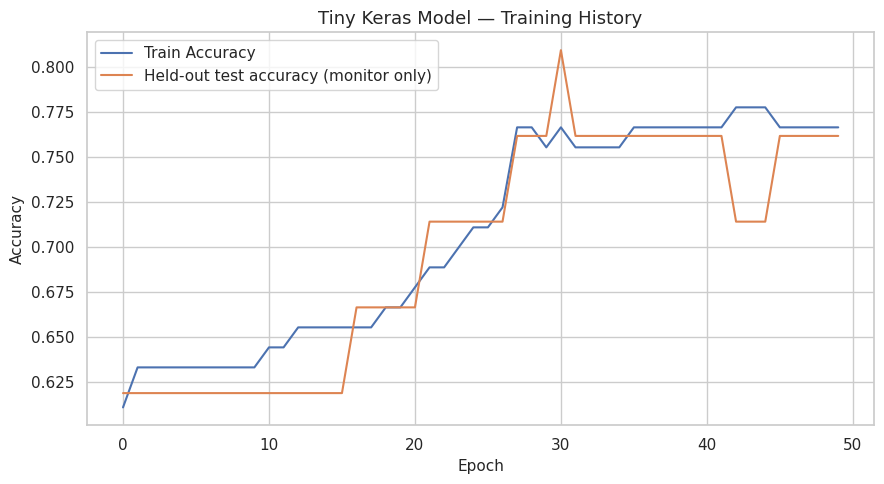

=== Keras float model - Test Set Performance ===
Test support: SAFE = 8, UNSAFE = 13
Accuracy : 0.7619
Precision: 0.7857   (UNSAFE = positive class)
Recall   : 0.8462   (UNSAFE recall)
F1-score : 0.8148
SAFE recall (true-negative rate): 0.6250
Balanced accuracy               : 0.7356
Confusion Matrix layout:
            Pred SAFE   Pred UNSAFE
True SAFE      TN=5        FP=3
True UNSAFE    FN=2        TP=11


In [23]:
if len(X_train) == 0:
    print("Tiny Keras model training skipped — no training data available yet.")
    keras_model = None
    feature_scaler = None
    X_train_scaled = X_test_scaled = None
    keras_probs = keras_predictions = keras_metrics = None
else:
    # --- Feature scaling (parameters saved for reuse at TFLite inference time) ---
    feature_scaler = StandardScaler()
    X_train_scaled = feature_scaler.fit_transform(X_train.values).astype(np.float32)
    X_test_scaled = feature_scaler.transform(X_test.values).astype(np.float32)

    scaler_params = {
        "mean": feature_scaler.mean_.tolist(),
        "scale": feature_scaler.scale_.tolist(),
        "feature_order": PRIMARY_FEATURE_COLS,
    }
    with open(MODELS_DIR / "feature_scaler.json", "w") as f:
        json.dump(scaler_params, f, indent=2)
    print("Feature scaler parameters saved to:", MODELS_DIR / "feature_scaler.json")

    # --- Tiny Keras model: TFLite deployment target (NOT the primary classifier) ---
    keras_model = keras.Sequential([
        keras.layers.Input(shape=(len(PRIMARY_FEATURE_COLS),)),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(8, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ], name="tiny_tflite_deployment_model")

    keras_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    keras_model.summary()

    history = keras_model.fit(
        X_train_scaled, y_train.values,
        validation_data=(X_test_scaled, y_test.values),
        epochs=KERAS_EPOCHS,
        batch_size=KERAS_BATCH_SIZE,
        verbose=0,
    )

    print(f"\nFinal training accuracy  : {history.history['accuracy'][-1]:.4f}")
    print(f"Final held-out test accuracy (monitor only): {history.history['val_accuracy'][-1]:.4f}")

    fig, ax = plt.subplots()
    ax.plot(history.history["accuracy"], label="Train Accuracy")
    ax.plot(history.history["val_accuracy"], label="Held-out test accuracy (monitor only)")
    ax.set_title("Tiny Keras Model — Training History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "keras_training_history.png", dpi=150)
    plt.show()

    # --- Explicit evaluation of the Keras model (same honest metrics as the Decision Tree) ---
    keras_probs = keras_model.predict(X_test_scaled, verbose=0).ravel()
    keras_predictions = (keras_probs >= 0.5).astype(int)
    keras_metrics = evaluate_binary("Keras float model", y_test, keras_predictions, show_report=False)

# Step 12 — TensorFlow Lite Conversion

## Purpose
Convert the tiny Keras model (trained above) into two TensorFlow Lite variants: a plain **Float32** model and a **post-training INT8 quantized** model.

## Method
- **Float32 conversion:** direct `tf.lite.TFLiteConverter` conversion with no quantization — establishes the size/behaviour baseline.
- **INT8 quantization:** uses post-training full-integer quantization with a **representative dataset function built from the training set only** (never the test set, to avoid calibration leakage).
- Quantization matters for TinyML because it reduces model size (typically ~4x for INT8 vs Float32) and can significantly speed up inference on constrained hardware, at a small, measurable accuracy cost — which is precisely what Step 13's size comparison and Step 14/15's inference evaluation are designed to quantify.

## Implementation
Standard `tf.lite.TFLiteConverter.from_keras_model()` calls; the representative dataset generator yields batches of `X_train_scaled`.

## Output / Interpretation
Two `.tflite` files saved under `outputs/models/`: `model_float32.tflite` and `model_int8.tflite`. No file sizes are asserted here — they are measured for real in Step 13.


In [24]:
if keras_model is None:
    print("TFLite conversion skipped — no trained Keras model available yet.")
    float32_tflite_path = int8_tflite_path = None
    int8_is_full_integer = False
else:
    # --- 1. Float32 TFLite conversion ---
    converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    tflite_fp32_model = converter_fp32.convert()

    float32_tflite_path = MODELS_DIR / "model_float32.tflite"
    with open(float32_tflite_path, "wb") as f:
        f.write(tflite_fp32_model)
    print(f"Float32 TFLite model saved to: {float32_tflite_path}")

    # --- 2. INT8 quantized TFLite conversion ---
    def representative_dataset():
        """Yields calibration batches from the TRAINING set only (never test data)."""
        for i in range(X_train_scaled.shape[0]):
            sample = X_train_scaled[i:i + 1].astype(np.float32)
            yield [sample]

    print(f"Calibration data: {X_train_scaled.shape[0]} TRAINING samples (test data are never used).")
    int8_is_full_integer = True
    converter_int8 = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_int8.representative_dataset = representative_dataset
    converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_int8.inference_input_type = tf.int8
    converter_int8.inference_output_type = tf.int8

    try:
        tflite_int8_model = converter_int8.convert()
        int8_tflite_path = MODELS_DIR / "model_int8.tflite"
        with open(int8_tflite_path, "wb") as f:
            f.write(tflite_int8_model)
        print(f"INT8 quantized TFLite model saved to: {int8_tflite_path}")
    except Exception as e:
        print(f"[WARNING] Full INT8 conversion failed ({e}); falling back to dynamic-range quantization.")
        int8_is_full_integer = False
        converter_dyn = tf.lite.TFLiteConverter.from_keras_model(keras_model)
        converter_dyn.optimizations = [tf.lite.Optimize.DEFAULT]
        tflite_int8_model = converter_dyn.convert()
        int8_tflite_path = MODELS_DIR / "model_int8.tflite"
        with open(int8_tflite_path, "wb") as f:
            f.write(tflite_int8_model)
        print(f"Dynamic-range quantized TFLite model saved to: {int8_tflite_path}")

Saved artifact at '/tmp/tmp0o8qb_cj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134092649910288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134092649917584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134092649919312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134092660903952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134092649921616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134092660910288: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 TFLite model saved to: outputs/models/model_float32.tflite
Calibration data: 90 TRAINING samples (test data are never used).
Saved artifact at '/tmp/tmp7_eu5xoq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, na

# Step 13 — TFLite Model (Verification & Size Comparison)

## Purpose
Verify that both `.tflite` files were actually written to disk, and compare their real file sizes.

## Method
- Check file existence and read `os.path.getsize()` for each model.
- Build a comparison table (`Model | Size (KB)`).
- Compute the actual size-reduction percentage of INT8 vs Float32 — computed only from measured byte counts, never assumed.

## Implementation
Simple filesystem inspection — no numbers are hard-coded.



Float32 model path: outputs/models/model_float32.tflite  |  3292 bytes  |  3.21 KB
INT8    model path: outputs/models/model_int8.tflite  |  3432 bytes  |  3.35 KB

Size reduction (INT8 vs Float32): -4.25%

             Model  Size (KB)
0  Float32 TFLite       3.21
1     INT8 TFLite       3.35


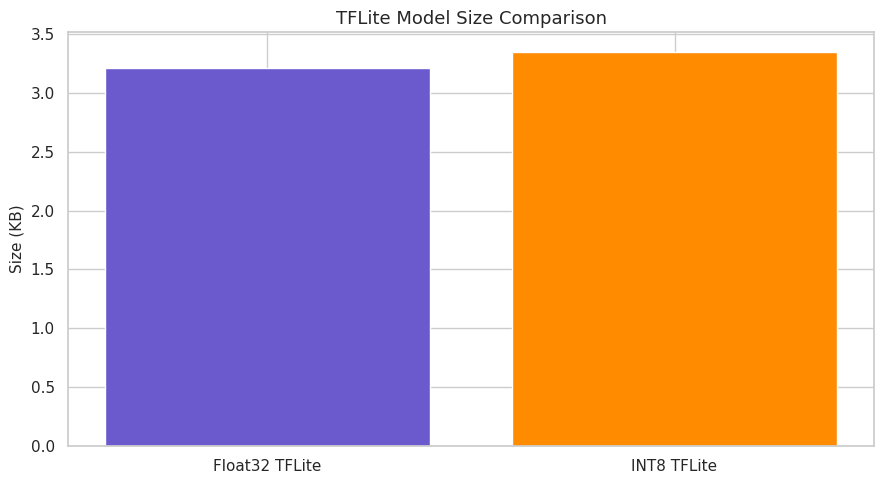

In [25]:
if float32_tflite_path is None or not float32_tflite_path.exists() or not int8_tflite_path.exists():
    print("TFLite model size comparison not available until data is provided.")
    size_comparison_df = pd.DataFrame(columns=["Model", "Size (KB)"])
    size_reduction_pct = None
else:
    fp32_size_bytes = os.path.getsize(float32_tflite_path)
    int8_size_bytes = os.path.getsize(int8_tflite_path)

    fp32_size_kb = fp32_size_bytes / 1024
    int8_size_kb = int8_size_bytes / 1024

    size_reduction_pct = (1 - (int8_size_bytes / fp32_size_bytes)) * 100 if fp32_size_bytes > 0 else None

    print(f"Float32 model path: {float32_tflite_path}  |  {fp32_size_bytes} bytes  |  {fp32_size_kb:.2f} KB")
    print(f"INT8    model path: {int8_tflite_path}  |  {int8_size_bytes} bytes  |  {int8_size_kb:.2f} KB")
    print(f"\nSize reduction (INT8 vs Float32): {size_reduction_pct:.2f}%")

    size_comparison_df = pd.DataFrame({
        "Model": ["Float32 TFLite", "INT8 TFLite"],
        "Size (KB)": [round(fp32_size_kb, 2), round(int8_size_kb, 2)],
    })
    print("\n", size_comparison_df)

    fig, ax = plt.subplots()
    ax.bar(size_comparison_df["Model"], size_comparison_df["Size (KB)"], color=["slateblue", "darkorange"])
    ax.set_title("TFLite Model Size Comparison")
    ax.set_ylabel("Size (KB)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "tflite_size_comparison.png", dpi=150)
    plt.show()

# Step 14 — TensorFlow Lite Inference

**Run TensorFlow Lite inference inside the notebook (Colab/Jupyter) for evaluation and testing.**

## Purpose
Load both `.tflite` models (Float32 and INT8) with `tf.lite.Interpreter` and run inference on the held-out test set **inside this notebook**. This is a notebook-based evaluation of the exported models, not a smartphone, Android or edge-hardware deployment.

## Method
- A shared helper inspects the interpreter's **actual** input/output tensor details (dtype, scale, zero point) instead of assuming a datatype.
- Inputs are standardised with the same `feature_scaler` fitted on the training split. For an integer input tensor they are quantised as `q = clip(round(x / input_scale + input_zero_point), dtype_min, dtype_max)`. A float input tensor is fed unchanged.
- Outputs of an integer output tensor are dequantised as `p = (q - output_zero_point) * output_scale`. A float output is used directly.
- Probabilities are thresholded at 0.5 to give SAFE (0) / UNSAFE (1) and evaluated with the same `evaluate_binary()` helper as the other models.
- The INT8 predictions are also compared with the Keras predictions (agreement), which isolates quantization effects from classification quality.

## Output
`tflite_fp32_predictions`, `tflite_predictions` (INT8), their metrics, and an agreement check against the Keras model. As in Step 11, results are only meaningful if `y_test` contains both classes; the helper prints a warning otherwise.

In [26]:
def quantize_input(x, details):
    """Map float features to the interpreter's input dtype using its own scale/zero-point."""
    scale, zero_point = details["quantization"]
    dtype = details["dtype"]
    if dtype in (np.int8, np.uint8) and scale > 0:
        info = np.iinfo(dtype)
        return np.clip(np.round(x / scale + zero_point), info.min, info.max).astype(dtype)
    return x.astype(dtype)


def dequantize_output(raw, details):
    """Map the interpreter's raw output back to a float probability."""
    scale, zero_point = details["quantization"]
    if details["dtype"] in (np.int8, np.uint8) and scale > 0:
        return (raw.astype(np.float32) - zero_point) * scale
    return raw.astype(np.float32)


def run_tflite(model_path, X_scaled):
    """Run a .tflite model sample by sample. Returns (probabilities, interpreter, input_details, output_details)."""
    interp = tf.lite.Interpreter(model_path=str(model_path))
    interp.allocate_tensors()
    in_d = interp.get_input_details()[0]
    out_d = interp.get_output_details()[0]
    probs = []
    for i in range(X_scaled.shape[0]):
        interp.set_tensor(in_d["index"], quantize_input(X_scaled[i:i + 1], in_d))
        interp.invoke()
        probs.append(float(dequantize_output(interp.get_tensor(out_d["index"]), out_d).squeeze()))
    return np.array(probs), interp, in_d, out_d


if (int8_tflite_path is None or not int8_tflite_path.exists()
        or X_test_scaled is None or len(X_test_scaled) == 0):
    print("TFLite inference not available until data is provided.")
    tflite_predictions = tflite_fp32_predictions = None
    tflite_fp32_metrics = tflite_int8_metrics = None
else:
    # ---------------- Float32 TFLite ----------------
    fp32_probs, interpreter_fp32, fp32_in, fp32_out = run_tflite(float32_tflite_path, X_test_scaled)
    print("Float32 TFLite input  :", fp32_in["dtype"].__name__, fp32_in["quantization"])
    print("Float32 TFLite output :", fp32_out["dtype"].__name__, fp32_out["quantization"])
    tflite_fp32_predictions = (fp32_probs >= 0.5).astype(int)
    tflite_fp32_metrics = evaluate_binary("TFLite Float32", y_test, tflite_fp32_predictions, show_report=False)

    # ---------------- INT8 TFLite ----------------
    int8_probs, interpreter, input_details, output_details = run_tflite(int8_tflite_path, X_test_scaled)
    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]
    print("\nINT8 model - actual tensor details (inspected, not assumed):")
    print(f"  input : dtype={input_details['dtype'].__name__}, scale={input_scale}, zero_point={input_zero_point}")
    print(f"  output: dtype={output_details['dtype'].__name__}, scale={output_scale}, zero_point={output_zero_point}")
    if not int8_is_full_integer:
        print("  [NOTE] Full-integer conversion failed earlier; this is the dynamic-range fallback "
              "(float input/output).")
    tflite_predictions = (int8_probs >= 0.5).astype(int)
    tflite_int8_metrics = evaluate_binary("TFLite INT8", y_test, tflite_predictions, show_report=False)
    tflite_accuracy = tflite_int8_metrics["accuracy"]

    # ---------------- Quantization fidelity ----------------
    print("\n=== Agreement with the Keras float model (quantization effect) ===")
    print(f"Float32 TFLite vs Keras : {np.mean(tflite_fp32_predictions == keras_predictions):.4f}")
    print(f"INT8    TFLite vs Keras : {np.mean(tflite_predictions == keras_predictions):.4f}")
    print(f"Max |prob(INT8) - prob(Keras)| : {np.max(np.abs(int8_probs - keras_probs)):.4f}")

    comparison_df = pd.DataFrame({
        "true_label": y_test.values,
        "keras_pred": keras_predictions,
        "tflite_fp32_pred": tflite_fp32_predictions,
        "tflite_int8_pred": tflite_predictions,
    })
    print("\nPredictions vs true labels (test set):")
    print(comparison_df.to_string(index=False))

Float32 TFLite input  : float32 (0.0, 0)
Float32 TFLite output : float32 (0.0, 0)
=== TFLite Float32 - Test Set Performance ===
Test support: SAFE = 8, UNSAFE = 13
Accuracy : 0.7619
Precision: 0.7857   (UNSAFE = positive class)
Recall   : 0.8462   (UNSAFE recall)
F1-score : 0.8148
SAFE recall (true-negative rate): 0.6250
Balanced accuracy               : 0.7356
Confusion Matrix layout:
            Pred SAFE   Pred UNSAFE
True SAFE      TN=5        FP=3
True UNSAFE    FN=2        TP=11

INT8 model - actual tensor details (inspected, not assumed):
  input : dtype=int8, scale=0.031981199979782104, zero_point=-27
  output: dtype=int8, scale=0.00390625, zero_point=-128
=== TFLite INT8 - Test Set Performance ===
Test support: SAFE = 8, UNSAFE = 13
Accuracy : 0.7619
Precision: 0.7857   (UNSAFE = positive class)
Recall   : 0.8462   (UNSAFE recall)
F1-score : 0.8148
SAFE recall (true-negative rate): 0.6250
Balanced accuracy               : 0.7356
Confusion Matrix layout:
            Pred SAFE  

# Step 15 — Deployment Metrics

**Notebook-based TFLite inference benchmarks** — no physical edge deployment is performed; these are measurements of the exported `.tflite` models running inside this Colab/Jupyter session.

## Purpose
Benchmark the practical deployment characteristics of the **Float32** and **INT8** TFLite models side by side: size, per-sample inference latency, and an in-memory footprint proxy.

## Method
- **Model size:** measured in Step 13 (KB).
- **Inference time:** `N_BENCHMARK_ITERATIONS = 200` repeated single-sample inferences per model (after a short un-timed warm-up), reporting mean, median and standard deviation in milliseconds. A single inference is never used because it is far too noisy.
- **Memory footprint:** the size of the loaded `.tflite` buffer as a proxy (precise RSS/heap measurement is environment dependent and is not claimed).

## Interpretation caveat
For a model with a few hundred parameters, the measured time is dominated by Python/interpreter call overhead on a desktop or cloud CPU. A faster INT8 result is not guaranteed here and says little about microcontroller performance.

=== Notebook-based TFLite Inference Benchmarks ===
Iterations per model: 200 (after 20 warm-up runs)
         Model  Size (KB)  Mean (ms)  Median (ms)  Std (ms)
Float32 TFLite     3.2100     0.0078       0.0047    0.0306
   INT8 TFLite     3.3500     0.0044       0.0029    0.0043

Loaded INT8 model buffer: 3.35 KB (memory-footprint proxy)
Mean latency ratio FP32/INT8: 1.77x (>1 means INT8 faster; at this model size the difference is dominated by call overhead)


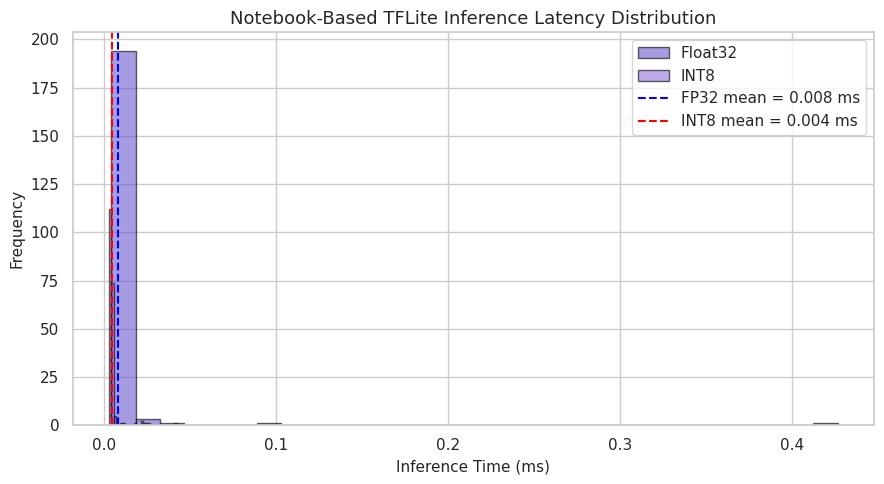

In [27]:
N_BENCHMARK_ITERATIONS = 200
N_WARMUP_ITERATIONS = 20


def benchmark_tflite(interp, in_d, out_d, sample_float, n_iter=N_BENCHMARK_ITERATIONS, n_warmup=N_WARMUP_ITERATIONS):
    """Time n_iter single-sample inferences (set_tensor + invoke + get_tensor) after warm-up."""
    sample_q = quantize_input(sample_float, in_d)
    for _ in range(n_warmup):
        interp.set_tensor(in_d["index"], sample_q)
        interp.invoke()
    times = []
    for _ in range(n_iter):
        start = time.perf_counter()
        interp.set_tensor(in_d["index"], sample_q)
        interp.invoke()
        _ = interp.get_tensor(out_d["index"])
        times.append((time.perf_counter() - start) * 1000.0)
    return np.array(times)


if (int8_tflite_path is None or not int8_tflite_path.exists()
        or X_test_scaled is None or len(X_test_scaled) == 0):
    print("Deployment benchmarking not available until data is provided.")
    mean_inference_time_ms = median_inference_time_ms = None
    mean_fp32_time_ms = median_fp32_time_ms = None
else:
    sample = X_test_scaled[0:1]
    fp32_times_ms = benchmark_tflite(interpreter_fp32, fp32_in, fp32_out, sample)
    inference_times_ms = benchmark_tflite(interpreter, input_details, output_details, sample)

    mean_fp32_time_ms, median_fp32_time_ms = float(np.mean(fp32_times_ms)), float(np.median(fp32_times_ms))
    std_fp32_time_ms = float(np.std(fp32_times_ms))
    mean_inference_time_ms, median_inference_time_ms = float(np.mean(inference_times_ms)), float(np.median(inference_times_ms))
    std_inference_time_ms = float(np.std(inference_times_ms))

    fp32_size_kb_final = os.path.getsize(float32_tflite_path) / 1024
    int8_size_kb_final = os.path.getsize(int8_tflite_path) / 1024
    model_buffer_kb = len(open(int8_tflite_path, "rb").read()) / 1024  # in-memory .tflite buffer size

    bench_df = pd.DataFrame({
        "Model": ["Float32 TFLite", "INT8 TFLite"],
        "Size (KB)": [round(fp32_size_kb_final, 2), round(int8_size_kb_final, 2)],
        "Mean (ms)": [mean_fp32_time_ms, mean_inference_time_ms],
        "Median (ms)": [median_fp32_time_ms, median_inference_time_ms],
        "Std (ms)": [std_fp32_time_ms, std_inference_time_ms],
    })
    print("=== Notebook-based TFLite Inference Benchmarks ===")
    print(f"Iterations per model: {N_BENCHMARK_ITERATIONS} (after {N_WARMUP_ITERATIONS} warm-up runs)")
    print(bench_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    print(f"\nLoaded INT8 model buffer: {model_buffer_kb:.2f} KB (memory-footprint proxy)")
    print(f"Mean latency ratio FP32/INT8: {mean_fp32_time_ms / mean_inference_time_ms:.2f}x "
          f"(>1 means INT8 faster; at this model size the difference is dominated by call overhead)")

    fig, ax = plt.subplots()
    ax.hist(fp32_times_ms, bins=30, alpha=0.6, color="slateblue", edgecolor="black", label="Float32")
    ax.hist(inference_times_ms, bins=30, alpha=0.6, color="mediumpurple", edgecolor="black", label="INT8")
    ax.axvline(mean_fp32_time_ms, color="blue", linestyle="--", label=f"FP32 mean = {mean_fp32_time_ms:.3f} ms")
    ax.axvline(mean_inference_time_ms, color="red", linestyle="--", label=f"INT8 mean = {mean_inference_time_ms:.3f} ms")
    ax.set_title("Notebook-Based TFLite Inference Latency Distribution")
    ax.set_xlabel("Inference Time (ms)")
    ax.set_ylabel("Frequency")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "inference_latency_distribution.png", dpi=150)
    plt.show()

# Final Results Summary

## Purpose
Dynamically assemble a single summary table of every key metric computed throughout this notebook. Any metric that could not be computed (because real data has not yet been supplied) is explicitly reported as **"Not available until data is provided"** rather than being invented.

## Method
Pulls directly from the variables computed in Steps 3–15: trial/sample/window counts, class balance, Decision Tree metrics, TFLite model sizes and size reduction, and inference-time statistics.

## Implementation
Pure aggregation/formatting code — no new computation, no fabricated fallback values.

## Output / Interpretation
`summary_df`: a single-glance table suitable for inclusion in a lab report, fully derived from this notebook's own upstream results.


In [28]:
def fmt(value, suffix="", precision=4):
    if value is None:
        return "Not available until data is provided"
    if isinstance(value, (int, np.integer)):
        return f"{value}{suffix}"
    return f"{value:.{precision}f}{suffix}"


n_trials_final = master_df["trial_id"].nunique() if not master_df.empty else None
n_raw_samples_final = len(master_df) if not master_df.empty else None
n_windows_final = len(features_df) if not features_df.empty else None
n_safe_windows = int((features_df["label"] == 0).sum()) if not features_df.empty and "label" in features_df.columns else None
n_unsafe_windows = int((features_df["label"] == 1).sum()) if not features_df.empty and "label" in features_df.columns else None

summary_rows = [
    ("Selected window size (s) - from ablation", f"{WINDOW_SIZE_SECONDS:g}"),
    ("Window overlap", f"{WINDOW_OVERLAP:g}"),
    ("Number of trials", fmt(n_trials_final, precision=0)),
    ("Number of raw samples", fmt(n_raw_samples_final, precision=0)),
    ("Number of windows", fmt(n_windows_final, precision=0)),
    ("SAFE windows", fmt(n_safe_windows, precision=0)),
    ("UNSAFE windows", fmt(n_unsafe_windows, precision=0)),
    ("Training trials / windows", f"{len(train_trials)} / {len(X_train)}" if not features_df.empty else "Not available until data is provided"),
    ("Testing trials / windows", f"{len(test_trials)} / {len(X_test)}" if not features_df.empty else "Not available until data is provided"),
    ("Train SAFE / UNSAFE windows", "{} / {}".format(*class_counts(y_train)) if not features_df.empty else "Not available until data is provided"),
    ("Test SAFE / UNSAFE windows", "{} / {}".format(*class_counts(y_test)) if not features_df.empty else "Not available until data is provided"),
    ("Test set contains both classes", str(test_has_both_classes) + ("" if test_has_both_classes else "  (WARNING: metrics below are limited)")),
    ("Decision Tree accuracy", fmt(dt_accuracy)),
    ("Decision Tree precision", fmt(dt_precision)),
    ("Decision Tree recall", fmt(dt_recall)),
    ("Decision Tree F1-score", fmt(dt_f1)),
    ("Decision Tree balanced accuracy", fmt(dt_metrics["balanced_accuracy"]) if dt_metrics and dt_metrics["balanced_accuracy"] is not None else "Not defined (one-class test set)"),
    ("Decision Tree UNSAFE recall", fmt(dt_metrics["unsafe_recall"]) if dt_metrics and dt_metrics["unsafe_recall"] is not None else "Not defined (no UNSAFE in test)"),
    ("Decision Tree SAFE recall", fmt(dt_metrics["safe_recall"]) if dt_metrics and dt_metrics["safe_recall"] is not None else "Not defined (no SAFE in test)"),
    ("Keras accuracy (test)", fmt(keras_metrics["accuracy"]) if keras_metrics else fmt(None)),
    ("TFLite Float32 accuracy (test)", fmt(tflite_fp32_metrics["accuracy"]) if tflite_fp32_metrics else fmt(None)),
    ("TFLite INT8 accuracy (test)", fmt(tflite_int8_metrics["accuracy"]) if tflite_int8_metrics else fmt(None)),
    ("Float32 TFLite size (KB)",
     fmt(size_comparison_df.loc[size_comparison_df["Model"] == "Float32 TFLite", "Size (KB)"].values[0]
         if not size_comparison_df.empty else None, suffix=" KB", precision=2)),
    ("INT8 TFLite size (KB)",
     fmt(size_comparison_df.loc[size_comparison_df["Model"] == "INT8 TFLite", "Size (KB)"].values[0]
         if not size_comparison_df.empty else None, suffix=" KB", precision=2)),
    ("TFLite size reduction (%)", fmt(size_reduction_pct, suffix="%", precision=2)),
    ("Mean TFLite INT8 inference time (ms)", fmt(mean_inference_time_ms, suffix=" ms", precision=4)),
    ("Median TFLite INT8 inference time (ms)", fmt(median_inference_time_ms, suffix=" ms", precision=4)),
    ("Mean TFLite Float32 inference time (ms)", fmt(mean_fp32_time_ms, suffix=" ms", precision=4)),
    ("Median TFLite Float32 inference time (ms)", fmt(median_fp32_time_ms, suffix=" ms", precision=4)),
]

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
print(summary_df.to_string(index=False))

summary_df.to_csv(REPORTS_DIR / "final_results_summary.csv", index=False)
if not features_df.empty:
    features_df.to_csv(PROCESSED_DIR / "processed_features.csv", index=False)
    print(f"\nSaved processed features to: {PROCESSED_DIR / 'processed_features.csv'}")
print(f"Saved final summary to: {REPORTS_DIR / 'final_results_summary.csv'}")

print("\nNOTE: SAFE = pre-failure window inside a failure trial (not an independently recorded safe trial).")
print("Read every classification metric together with the test class counts above.")

                                   Metric     Value
 Selected window size (s) - from ablation         1
                           Window overlap       0.5
                         Number of trials        20
                    Number of raw samples     34761
                        Number of windows       111
                             SAFE windows        41
                           UNSAFE windows        70
                Training trials / windows   16 / 90
                 Testing trials / windows    4 / 21
              Train SAFE / UNSAFE windows   33 / 57
               Test SAFE / UNSAFE windows    8 / 13
           Test set contains both classes      True
                   Decision Tree accuracy    0.7143
                  Decision Tree precision    0.8182
                     Decision Tree recall    0.6923
                   Decision Tree F1-score    0.7500
          Decision Tree balanced accuracy    0.7212
              Decision Tree UNSAFE recall    0.6923
            

# Window-Size Ablation - Interpretation and Final Sanity Checks

This cell is data-driven: every number is printed from the executed run (no hard-coded results).

In [29]:
# ============ Data-driven ablation interpretation + final sanity checks ============
r = ablation_results[SELECTED_WINDOW_SECONDS]
f3 = lambda v: "n/a" if v is None or pd.isna(v) else f"{v:.3f}"

# ---- sanity checks on the executed notebook ----
assert set(np.unique(y_labels)) <= {SAFE, UNSAFE}
assert len(set(train_trials) & set(test_trials)) == 0
assert dt_metrics is not None and abs(dt_metrics["accuracy"] - r["metrics"]["accuracy"]) < 1e-12, "DT metrics differ from ablation record (stale?)"
assert tflite_fp32_metrics is not None and tflite_int8_metrics is not None and mean_inference_time_ms is not None
assert float32_tflite_path.exists() and int8_tflite_path.exists()
assert len(X_train_scaled) == len(X_train) and len(X_test_scaled) == len(X_test)
print("[SANITY CHECKS PASSED] labels in {0,1}; 0 train/test trial overlap; DT metrics match ablation record; "
      "TFLite models exist; inference + latency measured on the selected window.\n")

print("=== WINDOW-SIZE ABLATION: SUMMARY ===")
print(ablation_df[core_cols].to_string(index=False, float_format=lambda v: f"{v:.3f}", na_rep="n/a"))
print(f"\nSelected window: {SELECTED_WINDOW_SECONDS:g} s")
print("Rule:", SELECTION_REASON)
print()
print("--- Selected window: model results (test set) ---")
print(f"Windows: {r['n_windows']} (SAFE {r['n_safe']}, UNSAFE {r['n_unsafe']}) from {r['usable_trials']} usable trials; "
      f"train SAFE/UNSAFE = {r['train_safe']}/{r['train_unsafe']}, test SAFE/UNSAFE = {r['test_safe']}/{r['test_unsafe']}")
print(f"Decision Tree : accuracy {f3(dt_metrics['accuracy'])}, balanced acc {f3(dt_metrics['balanced_accuracy'])}, "
      f"SAFE recall {f3(dt_metrics['safe_recall'])}, UNSAFE recall {f3(dt_metrics['unsafe_recall'])}, F1 {f3(dt_metrics['f1'])}")
for nm, mm in [("Keras float    ", keras_metrics), ("TFLite Float32 ", tflite_fp32_metrics), ("TFLite INT8    ", tflite_int8_metrics)]:
    print(f"{nm}: accuracy {f3(mm['accuracy'])}, balanced acc {f3(mm['balanced_accuracy'])}, "
          f"SAFE recall {f3(mm['safe_recall'])}, UNSAFE recall {f3(mm['unsafe_recall'])}, F1 {f3(mm['f1'])}")
print(f"Latency (200 runs): FP32 mean {mean_fp32_time_ms:.4f} ms, INT8 mean {mean_inference_time_ms:.4f} ms")
if r["n_valid_splits"]:
    print(f"Stability: DT balanced accuracy over {r['n_valid_splits']} valid group-aware splits = "
          f"{r['robust_df']['bal_acc'].mean():.3f} +/- {r['robust_df']['bal_acc'].std(ddof=0):.3f}")

print("\n--- Viva explanation (auto-filled from the executed run) ---")
print(f"I performed a window-size ablation using {', '.join(f'{w:g}' for w in ABLATION_WINDOW_SIZES)} seconds. The original 3-second window produced only "
      f"{ablation_results[3.0]['n_windows']} usable windows ({ablation_results[3.0]['n_safe']} SAFE), so I investigated shorter windows. I kept the 50% overlap, the six "
      f"statistical features, the same Decision Tree / Keras configuration, the same trial segmentation and a trial-aware train/test split with "
      f"zero train/test trial overlap. I compared class coverage and balanced evaluation metrics rather than accuracy alone. The final window was "
      f"{SELECTED_WINDOW_SECONDS:g} s, giving {r['n_windows']} windows ({r['n_safe']} SAFE / {r['n_unsafe']} UNSAFE), test SAFE/UNSAFE = {r['test_safe']}/{r['test_unsafe']}, "
      f"and Decision Tree balanced accuracy {f3(dt_metrics['balanced_accuracy'])} (SAFE recall {f3(dt_metrics['safe_recall'])}). It was chosen for the best balance of temporal resolution, "
      f"class representation and valid evaluation. Because the dataset is small and has no independently recorded SAFE trials, this is a proof-of-concept, not a real-world performance estimate.")

[SANITY CHECKS PASSED] labels in {0,1}; 0 train/test trial overlap; DT metrics match ablation record; TFLite models exist; inference + latency measured on the selected window.

=== WINDOW-SIZE ABLATION: SUMMARY ===
Window Size  Total Windows  SAFE  UNSAFE  SAFE %  Usable Trials  Train SAFE  Train UNSAFE  Test SAFE  Test UNSAFE  Accuracy  Balanced Accuracy  SAFE Recall  UNSAFE Recall    F1
        3 s             18     2      16  11.100             16           1            13          1            3     0.750              0.500        0.000          1.000 0.857
        1 s            111    41      70  36.900             20          33            57          8           13     0.714              0.721        0.750          0.692 0.750
      0.5 s            249   113     136  45.400             20          90           111         23           25     0.771              0.766        0.652          0.880 0.800
     0.25 s            533   263     270  49.300             20         207  

# Conclusion

## 1. What Was Implemented
This notebook implements the full 15-step workflow for a lightweight, edge-deployable payload-safety classifier, built entirely from a single continuous phyphox gyroscope recording:

- Smartphone + phyphox acquisition of one continuous gyroscope stream (Steps 1–2), restricted to gyroscope **X** and **Y** only.
- Recovery of the 20 physically observed fall events from that continuous signal by matching independently recorded stopwatch times to gyroscope timestamps, and segmentation into 20 trial-level slices (Step 3).
- Data cleaning, per-trial sampling-rate diagnostics, and visual inspection (Step 4).
- A **window-size ablation study** (3.0, 1.0, 0.5 and 0.25 s; 50 % overlap; fixed trial segmentation; identical features, labels, Decision Tree and group-aware split) that selects the window used by the rest of the pipeline using class coverage, evaluation validity and balanced metrics rather than accuracy alone.
- Fixed-length, per-trial time-series windowing with configurable overlap, at the selected window size (Step 5).
- Extraction of a six-feature vector (`X_mean, X_std, X_rms, Y_mean, Y_std, Y_rms`) per window (Step 6), assembled into a feature matrix (Step 7).
- Window-level SAFE (0) / UNSAFE (1) labelling from each trial's matched fall time (Step 8), followed by a **trial-aware (group-based)** train/test split that prevents leakage between overlapping windows of the same trial and, where the data allow it, guarantees that both classes appear in train and in test (Step 9), with explicit class-distribution diagnostics.
- A `DecisionTreeClassifier` (`max_depth = 5`) as the primary lightweight classifier (Step 10) and an evaluation that checks class coverage before reporting metrics (Step 11).
- A separate, deliberately small Keras network (6 → 16 → 8 → 1) trained on the same features purely to demonstrate TensorFlow Lite conversion (Steps 12–13): Float32 and INT8 post-training quantization, with the representative dataset taken from the **training** split only.
- In-notebook inference for both TFLite models with quantization parameters read from the actual tensor details (Step 14), and a 200-iteration latency benchmark of Float32 vs INT8 (Step 15).
- An experimental estimate of the coefficient of static friction, μs, from the observed critical angular velocity (physics analysis section).

## 2. How to Read the Results
The numerical results (class counts per split, Decision Tree / Keras / TFLite metrics, model sizes, latencies) are printed by the cells above and collected in `summary_df`; they are not hard-coded here so that this text can never disagree with a re-run.

- The ablation table lists, for each window size, the number of windows, SAFE/UNSAFE counts, usable trials, train/test class coverage and Decision Tree metrics. The original 3.0 s window gave only 18 windows (2 SAFE) in the first executed version of this notebook; the effect of shorter windows is quantified by the ablation, not assumed.
- Because the split is trial-aware, SAFE windows can be placed in both train and test only when more than one trial carries SAFE windows. Even then, SAFE windows from the same trial are correlated, so SAFE-class metrics rest on few independent examples.
- Accuracy alone is misleading on this data: UNSAFE windows are the majority, so predicting UNSAFE for everything already scores highly. Read accuracy together with balanced accuracy, SAFE recall, UNSAFE recall, F1, the confusion matrix and the class counts.
- The INT8 vs Float32 size comparison, and the latency comparison, are measured for real in Steps 13 and 15. For a network of a few hundred parameters, quantization metadata can outweigh weight savings, so the INT8 file need not be smaller, and latency differences are dominated by interpreter call overhead.
- The static-friction coefficient (μs) is computed only if `PAYLOAD_MASS_KG`, `ROTATION_RADIUS_M` and `OMEGA_CRITICAL_OBSERVED` are supplied from real observations.

## 3. What the Experiment Demonstrates
- A full acquisition-to-deployment TinyML pipeline (windowing, features, classical model, Keras model, Float32 and INT8 TFLite conversion, in-notebook inference and benchmarking) can be built from a smartphone gyroscope stream and a manually timed stopwatch.
- A six-feature X/Y statistical descriptor is enough to build a model small enough (a few KB, microseconds per inference) to be plausible on constrained edge hardware.
- The evaluation procedure (group-aware split, leakage checks, class-coverage warnings) is reproducible and honest about what the data can support.

## 4. Limitations (summary; full discussion in the next section)
- All 20 trials come from **one continuous recording**; drift, mounting slack or handling artefacts of that single session appear in every trial.
- Event timing depends on a **human stopwatch reaction**, matched to the nearest gyroscope sample; this introduces an unquantified offset between recorded and true fall times.
- The number of windows, and especially of SAFE windows and SAFE-bearing trials, is small at every window size tested. The results are a proof-of-concept demonstration, not a reliable estimate of real-world performance.
- The physics μs estimate depends on inputs that must be supplied by the experimenter.

## 5. Final Statement
This notebook demonstrates, end-to-end, how a single continuous smartphone-gyroscope recording plus stopwatch-timed fall events can be turned into a lightweight pre-failure vs failure-window classifier and deployed as Float32 and INT8 TensorFlow Lite models, with measured sizes and latencies. It does **not** demonstrate general SAFE-trial vs UNSAFE-trial classification, and its accuracy figures must not be presented as evidence of real-world reliability.

# Dataset / Experimental Limitation

1. **All 20 physical trials contain a failure event.** The gyroscope was recorded continuously and each of the 20 segments ends in a fall.
2. **There are therefore no independently recorded SAFE trials.** Every trial-level label is UNSAFE.
3. **SAFE is defined at the window level**, as a window (of the selected size) that ends at or before the recorded failure time within a failure trial. SAFE windows are not recordings of a payload that stayed on the platform.
4. This makes the experiment closer to **pre-failure vs failure-window detection** than to **general SAFE-trial vs UNSAFE-trial classification**. The model may be learning properties of the seconds around a fall (for example the motion that precedes or accompanies it) rather than a property of safe operation.
5. A stronger experiment would need **additional independent SAFE trials**: recordings in which the payload stays on the platform for the whole run, collected in separate sessions and under the same conditions, ideally with several SAFE trials so that whole SAFE trials can be placed in both training and test sets, plus more failure trials.
6. The evaluation should **not** be interpreted as proof of general real-world SAFE/UNSAFE classification. SAFE windows are few and come from a few failure trials, so SAFE-class metrics are anecdotal even when the test set contains both classes - at every window size tested.
7. Shorter windows create more (highly overlapping, correlated) windows; they do not create independent SAFE trials. A better score at a shorter window is therefore not evidence of better real-world safety detection.

What was done to keep the evaluation honest: the split is trial-aware (no overlapping-window leakage), no samples were duplicated or synthesised (no SMOTE, no fake SAFE trials, no altered sensor data), class coverage of every split is printed before training, metrics are accompanied by explicit warnings when a class is missing or tiny, and INT8 calibration uses training data only.